# E-commerce Sales Analytics

## Project overview

The goal of this project is to analyze e-commerce sessions, sales, products,
traffic sources, devices, and subscriber behavior using SQL, Python,
Google BigQuery, and Tableau.

The project includes:

- data extraction from Google BigQuery using SQL;
- exploratory data analysis in Python;
- sales dynamics and seasonality analysis;
- statistical analysis of relationships and group differences;
- creation of an interactive dashboard in [Tableau Public](https://public.tableau.com/app/profile/dmytro.klymchuk/viz/E-commerceSalesCustomerAnalytics_17851452678650/SalesOverview#1).

In [192]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import pearsonr

from scipy import stats
from google.cloud import bigquery
from scipy.stats import (
    normaltest,
    ttest_rel,
    wilcoxon,
    friedmanchisquare,
    mannwhitneyu,
    kruskal,
    norm
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [24]:
PROJECT_ID = "data-analytics-mate"
DATASET_ID = "DA"

In [6]:
from google.cloud import bigquery

client = bigquery.Client(project="data-analytics-mate")

test_query = """
SELECT 1 AS connection_test
"""

test_df = client.query(test_query).to_dataframe(
    create_bqstorage_client=False
)

test_df

,connection_test
0,1


## Database Exploration

Before building the analytical dataset, we need to explore the database structure,
understand relationships between tables and identify the primary keys that will
be used for joining data.

In [7]:
def run_query(query: str) -> pd.DataFrame:
    """
    Execute SQL query in BigQuery
    and return pandas DataFrame.
    """

    return client.query(query).to_dataframe(
        create_bqstorage_client=False
    )

In [26]:
query = """
SELECT
    table_name
FROM `data-analytics-mate.DA.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""

tables = run_query(query)

tables

,table_name
0,ab_test
1,account
2,account_session
3,email_open
4,email_sent
5,email_sent_view
6,email_visit
7,event_params
8,order
9,paid_search_cost


In [27]:
def describe_table(table_name):

    query = f"""
    SELECT
        column_name,
        data_type,
        is_nullable

    FROM `{PROJECT_ID}.{DATASET_ID}.INFORMATION_SCHEMA.COLUMNS`

    WHERE table_name = '{table_name}'

    ORDER BY ordinal_position
    """

    return run_query(query)

In [11]:
describe_table("session")

,column_name,data_type,is_nullable
0,date,DATE,YES
1,ga_session_id,INT64,YES


In [28]:
def preview_table(table_name, limit=5):

    query = f"""
    SELECT *

    FROM `{PROJECT_ID}.{DATASET_ID}.{table_name}`

    LIMIT {limit}
    """

    return run_query(query)

In [13]:
preview_table("product")

,item_id,name,category,price,short_description
0,40296599,KURA,Beds,125.00,Bed tent
1,10311228,KURA,Beds,125.00,Bed tent
2,90332458,KURA,Beds,175.00,Bed tent with curtain
3,50393830,KURA,Beds,149.00,Bed tent with curtain
4,80253809,KURA,Beds,745.00,"Reversible bed, 90x200 cm"


In [29]:
def get_row_count(table_name):
    query = f"""
    SELECT COUNT(*) AS row_count
    FROM `{PROJECT_ID}.{DATASET_ID}.{table_name}`
    """
    return run_query(query).iloc[0, 0]

In [19]:
main_tables = [
    "session",
    "session_params",
    "order",
    "product",
    "account",
    "account_session"
]

In [18]:
row_counts = []

for table in main_tables:
    row_counts.append({
        "Table": table,
        "Rows": get_row_count(table)
    })

row_counts = pd.DataFrame(row_counts)

row_counts

,Table,Rows
0,session,349545
1,session_params,349545
2,order,33538
3,product,2962
4,account,45831
5,account_session,27945


In [30]:
def check_duplicates(table_name, key):

    query = f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT {key}) AS unique_keys
    FROM `{PROJECT_ID}.{DATASET_ID}.{table_name}`
    """

    return run_query(query)

In [21]:
check_duplicates("session", "ga_session_id")

,total_rows,unique_keys
0,349545,349545


In [22]:
check_duplicates("session_params", "ga_session_id")

,total_rows,unique_keys
0,349545,349545


In [23]:
check_duplicates("order", "ga_session_id")

,total_rows,unique_keys
0,33538,33538


In [31]:
describe_table("order")

,column_name,data_type,is_nullable
0,ga_session_id,INT64,YES
1,item_id,INT64,YES


In [32]:
preview_table("order")

,ga_session_id,item_id
0,7799937037,91415
1,4020421879,91415
2,6717382496,91415
3,2093497337,91415
4,9506718330,91415


In [33]:
describe_table("product")

,column_name,data_type,is_nullable
0,item_id,INT64,YES
1,name,STRING,YES
2,category,STRING,YES
3,price,FLOAT64,YES
4,short_description,STRING,YES


In [34]:
preview_table("product")

,item_id,name,category,price,short_description
0,40296599,KURA,Beds,125.00,Bed tent
1,10311228,KURA,Beds,125.00,Bed tent
2,90332458,KURA,Beds,175.00,Bed tent with curtain
3,50393830,KURA,Beds,149.00,Bed tent with curtain
4,80253809,KURA,Beds,745.00,"Reversible bed, 90x200 cm"


## SQL Data Extraction

In this section, we create the final analytical dataset that will be used
throughout the project.

The dataset combines information about:

- sessions;
- traffic sources;
- devices;
- products;
- subscribers.

The main table is **session**, because the project requires keeping all sessions,
including those without purchases or registered users.

In [35]:
with open("../sql/main_dataset.sql", "r") as file:
    query = file.read()

In [36]:
df = run_query(query)

In [37]:
df.shape

(349545, 19)

In [38]:
df.head()

,session_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,medium,traffic_source_name,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,short_description
0,2020-11-01,967742695,Americas,United States,desktop,Safari,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,9065007548,Asia,China,desktop,Chrome,Safari,Web,NaN,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3267062634,Americas,United States,desktop,Chrome,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
3,2020-11-01,8892952409,Americas,United States,mobile,Android Webview,<Other>,Web,ko,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
4,2020-11-01,1624570787,Asia,Turkey,desktop,<Other>,<Other>,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   session_date         349545 non-null  dbdate 
 1   ga_session_id        349545 non-null  Int64  
 2   continent            349545 non-null  str    
 3   country              349545 non-null  str    
 4   device               349545 non-null  str    
 5   browser              349545 non-null  str    
 6   mobile_model_name    349545 non-null  str    
 7   operating_system     349545 non-null  str    
 8   language             235279 non-null  str    
 9   medium               349545 non-null  str    
 10  traffic_source_name  349545 non-null  str    
 11  channel              349545 non-null  str    
 12  account_id           27945 non-null   Int64  
 13  is_verified          27945 non-null   Int64  
 14  is_unsubscribed      27945 non-null   Int64  
 15  category             33538 n

In [40]:
df.describe()

,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,"349,545.00","27,945.00","27,945.00","27,945.00","33,538.00"
mean,"4,992,250,296.63","659,005.07",0.72,0.17,953.30
std,"2,887,450,949.54","13,216.53",0.45,0.38,"1,317.00"
min,"1,205.00","636,133.00",0.00,0.00,3.00
25%,"2,493,646,855.00","647,576.00",0.00,0.00,170.00
50%,"4,988,476,074.00","658,952.00",1.00,0.00,445.00
75%,"7,491,286,508.00","670,414.00",1.00,0.00,"1,195.00"
max,"9,999,997,129.00","681,962.00",1.00,1.00,"9,585.00"


In [41]:
df.isna().sum()

session_date                0
ga_session_id               0
continent                   0
country                     0
device                      0
browser                     0
mobile_model_name           0
operating_system            0
language               114266
medium                      0
traffic_source_name         0
channel                     0
account_id             321600
is_verified            321600
is_unsubscribed        321600
category               316007
product_name           316007
price                  316007
short_description      316007
dtype: int64

In [42]:
df.nunique()

session_date               92
ga_session_id          349545
continent                   6
country                   108
device                      3
browser                     6
mobile_model_name          10
operating_system            6
language                    9
medium                      6
traffic_source_name         5
channel                     5
account_id              27945
is_verified                 2
is_unsubscribed             2
category                   14
product_name              550
price                     829
short_description        1476
dtype: int64

## Dataset Overview and Data Quality

This section examines the structure, data types, missing values and general
quality of the analytical dataset before performing the main analysis.

In [43]:
print(f"Rows: {len(df):,}")
print(f"Unique sessions: {df['ga_session_id'].nunique():,}")
print(f"Duplicated session IDs: {df['ga_session_id'].duplicated().sum():,}")

Rows: 349,545
Unique sessions: 349,545
Duplicated session IDs: 0


In [44]:
df["session_date"] = pd.to_datetime(df["session_date"])

In [45]:
df["email_verification_status"] = df["is_verified"].map({
    1: "Verified",
    0: "Not verified"
})

df["subscription_status"] = df["is_unsubscribed"].map({
    1: "Unsubscribed",
    0: "Subscribed"
})

In [46]:
df["has_purchase"] = df["product_name"].notna()
df["has_account"] = df["account_id"].notna()

In [48]:
analysis_start = df["session_date"].min()
analysis_end = df["session_date"].max()
number_of_days = df["session_date"].nunique()

print(f"Analysis period: {analysis_start.date()} — {analysis_end.date()}")
print(f"Number of unique dates: {number_of_days}")

Analysis period: 2020-11-01 — 2021-01-31
Number of unique dates: 92


In [49]:
expected_days = pd.date_range(
    start=analysis_start,
    end=analysis_end,
    freq="D"
)

missing_dates = expected_days.difference(df["session_date"].unique())

print(f"Expected calendar days: {len(expected_days)}")
print(f"Missing calendar days: {len(missing_dates)}")

Expected calendar days: 92
Missing calendar days: 0


In [50]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_values")
      .assign(
          missing_percentage=lambda x:
          x["missing_values"] / len(df) * 100
      )
      .sort_values("missing_percentage", ascending=False)
)

missing_summary

,missing_values,missing_percentage
account_id,321600,92.01
is_unsubscribed,321600,92.01
email_verification_status,321600,92.01
subscription_status,321600,92.01
is_verified,321600,92.01
category,316007,90.41
product_name,316007,90.41
price,316007,90.41
short_description,316007,90.41
language,114266,32.69


In [51]:
print(f"Sessions without purchase: {316_007 / 349_545:.2%}")
print(f"Sessions without account link: {321_600 / 349_545:.2%}")
print(f"Sessions without browser language: {114_266 / 349_545:.2%}")

Sessions without purchase: 90.41%
Sessions without account link: 92.01%
Sessions without browser language: 32.69%


In [52]:
categorical_columns = [
    "continent",
    "country",
    "device",
    "browser",
    "mobile_model_name",
    "operating_system",
    "language",
    "medium",
    "traffic_source_name",
    "channel",
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(15))


continent
continent
Americas     193179
Asia          83113
Europe        65135
Oceania        3703
Africa         3620
(not set)       795
Name: count, dtype: int64

country
country
United States     153470
India              32763
Canada             25994
United Kingdom     11003
France              6958
Spain               6505
Germany             6196
China               6066
Taiwan              5879
Italy               4859
Japan               4607
Singapore           4594
South Korea         4374
Netherlands         3941
Ukraine             3556
Name: count, dtype: int64

device
device
desktop    204429
mobile     137267
tablet       7849
Name: count, dtype: int64

browser
browser
Chrome             238460
Safari              83254
<Other>              8930
Edge                 8023
Firefox              6433
Android Webview      4445
Name: count, dtype: int64

mobile_model_name
mobile_model_name
Chrome        97254
iPhone        71326
Safari        70891
<Other>       70839
Chro

In [53]:
total_sessions = df["ga_session_id"].nunique()
purchase_sessions = df["has_purchase"].sum()
account_sessions = df["has_account"].sum()
total_revenue = df["price"].sum()

purchase_session_rate = purchase_sessions / total_sessions
revenue_per_session = total_revenue / total_sessions

print(f"Total sessions: {total_sessions:,}")
print(f"Purchase sessions: {purchase_sessions:,}")
print(f"Sessions linked to accounts: {account_sessions:,}")
print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Purchase-session rate: {purchase_session_rate:.2%}")
print(f"Revenue per session: ${revenue_per_session:,.2f}")

Total sessions: 349,545
Purchase sessions: 33,538
Sessions linked to accounts: 27,945
Total revenue: $31,971,731.10
Purchase-session rate: 9.59%
Revenue per session: $91.47


### Dataset overview findings

- The final dataset contains 349,545 rows and 19 original columns.
- Each row represents one website session.
- `ga_session_id` remains unique after all joins, indicating that the joins did
  not multiply session or revenue records.
- Product information is available for 33,538 sessions. Missing product values
  represent sessions without a purchase and are therefore structurally expected.
- Account information is available for 27,945 sessions. Missing account values
  indicate that no account creation was linked to the session.
- Browser language is missing for a substantial share of sessions and represents
  a genuine data-collection limitation.
- Some traffic fields contain non-null placeholders such as `(data deleted)`,
  `<Other>` and `Undefined`; these values should not be treated as ordinary
  missing values without considering their different meanings.
- Identifiers and binary flags are stored numerically but should not be interpreted
  as continuous numerical measures.

## Sales and Customer Analysis

This section analyzes sales distribution across geographic regions, product
categories, devices and traffic sources. It also examines subscriber email
verification, subscription status and geographic distribution.

In [54]:
sales_df = df.loc[df["has_purchase"]].copy()

sales_df.shape

(33538, 23)

In [55]:
print(f"Sales rows: {len(sales_df):,}")
print(f"Unique purchase sessions: {sales_df['ga_session_id'].nunique():,}")
print(f"Missing prices: {sales_df['price'].isna().sum():,}")

Sales rows: 33,538
Unique purchase sessions: 33,538
Missing prices: 0


In [105]:
continent_sales = (
    sales_df.groupby("continent", as_index=False)
    .agg(
        total_revenue=("price", "sum"),
        purchase_sessions=("ga_session_id", "nunique")
    )
)

top_3_continents_revenue = (
    continent_sales
    .nlargest(3, "total_revenue")
)

top_3_continents_orders = (
    continent_sales
    .nlargest(3, "purchase_sessions")
)

display(top_3_continents_revenue)
display(top_3_continents_orders)

,continent,total_revenue,purchase_sessions
2,Americas,"17,665,280.00",18553
3,Asia,"7,601,298.30",7950
4,Europe,"5,934,624.20",6261


,continent,total_revenue,purchase_sessions
2,Americas,"17,665,280.00",18553
3,Asia,"7,601,298.30",7950
4,Europe,"5,934,624.20",6261


In [106]:
country_sales = (
    sales_df.groupby("country", as_index=False)
    .agg(
        total_revenue=("price", "sum"),
        purchase_sessions=("ga_session_id", "nunique")
    )
)

top_5_countries_revenue = (
    country_sales
    .nlargest(5, "total_revenue")
)

top_5_countries_orders = (
    country_sales
    .nlargest(5, "purchase_sessions")
)

display(top_5_countries_revenue)
display(top_5_countries_orders)

,country,total_revenue,purchase_sessions
104,United States,"13,943,553.90",14673
43,India,"2,809,762.00",3029
18,Canada,"2,437,921.00",2560
103,United Kingdom,"938,317.90",1029
33,France,"710,692.80",678


,country,total_revenue,purchase_sessions
104,United States,"13,943,553.90",14673
43,India,"2,809,762.00",3029
18,Canada,"2,437,921.00",2560
103,United Kingdom,"938,317.90",1029
33,France,"710,692.80",678


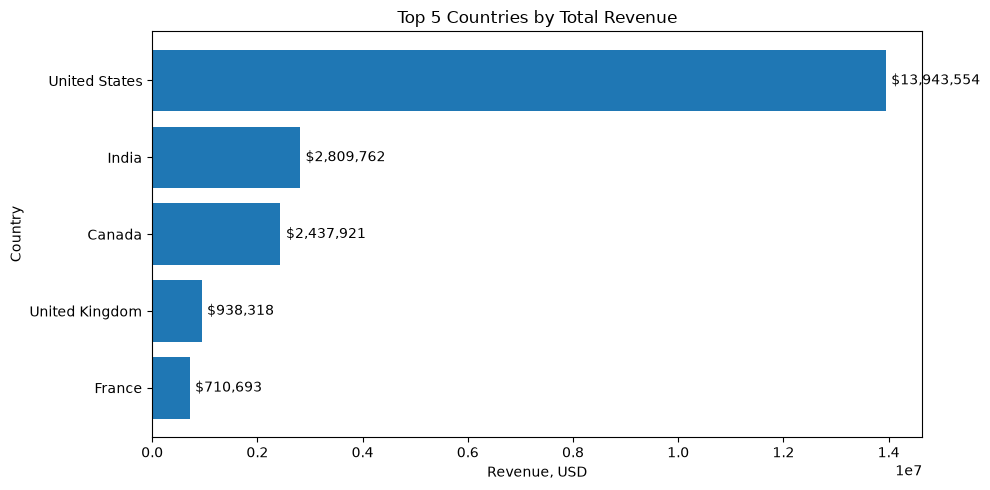

In [107]:
plot_data = (
    top_5_countries_revenue
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    plot_data["country"],
    plot_data["total_revenue"]
)

plt.bar_label(
    bars,
    labels=[f"${value:,.0f}" for value in plot_data["total_revenue"]],
    padding=4
)

plt.title("Top 5 Countries by Total Revenue")
plt.xlabel("Revenue, USD")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Geographic findings

- The top three continents by revenue are **Americas**, **Asia** and **Europe**.
- The top five countries by revenue are **United States, India, Canada, United Kingdom, France**.
- The ranking by revenue matches the ranking by purchase
  sessions. This means that geographical revenue differences are driven
  mostly by purchase volume.

In [108]:
category_sales = (
    sales_df.groupby("category", as_index=False)
    .agg(
        total_revenue=("price", "sum"),
        purchase_sessions=("ga_session_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

top_10_categories = category_sales.head(10)

top_10_categories

,category,total_revenue,purchase_sessions
12,Sofas & armchairs,"8,388,254.50",4301
5,Chairs,"6,147,748.80",5952
1,Beds,"4,919,725.00",2926
2,Bookcases & shelving units,"3,640,818.10",7630
3,Cabinets & cupboards,"2,336,499.50",2318
9,Outdoor furniture,"2,142,222.20",2229
13,Tables & desks,"1,790,307.50",2941
6,Chests of drawers & drawer units,"906,562.50",1452
0,Bar furniture,"735,503.00",1092
7,Children's furniture,"467,697.00",1702


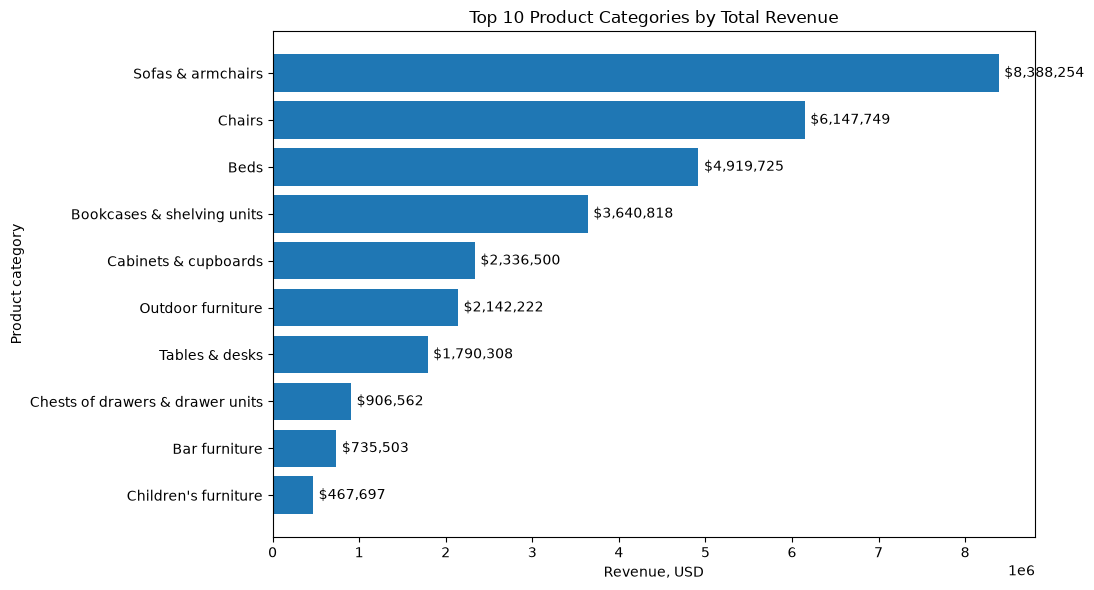

In [109]:
plot_data = top_10_categories.sort_values("total_revenue")

plt.figure(figsize=(11, 6))

bars = plt.barh(
    plot_data["category"],
    plot_data["total_revenue"]
)

plt.bar_label(
    bars,
    labels=[f"${value:,.0f}" for value in plot_data["total_revenue"]],
    padding=4
)

plt.title("Top 10 Product Categories by Total Revenue")
plt.xlabel("Revenue, USD")
plt.ylabel("Product category")
plt.tight_layout()
plt.show()

### Category findings

- **Sofas & armchairs** is the highest-revenue product category.
- It is followed by **Chairs** and **Beds**.
- The leading categories generate high revenue primarily because of relatively expensive products.

In [110]:
top_country = (
    country_sales
    .nlargest(1, "total_revenue")
    .iloc[0]["country"]
)

print(f"Highest-revenue country: {top_country}")

Highest-revenue country: United States


In [111]:
top_country_categories = (
    sales_df[sales_df["country"] == top_country]
    .groupby("category", as_index=False)
    .agg(total_revenue=("price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_country_categories

,category,total_revenue
12,Sofas & armchairs,"3,707,144.50"
5,Chairs,"2,619,773.80"
1,Beds,"2,213,058.00"
2,Bookcases & shelving units,"1,567,606.90"
3,Cabinets & cupboards,"994,545.50"
9,Outdoor furniture,"929,245.20"
13,Tables & desks,"777,865.00"
6,Chests of drawers & drawer units,"382,388.00"
0,Bar furniture,"330,805.00"
7,Children's furniture,"207,575.00"


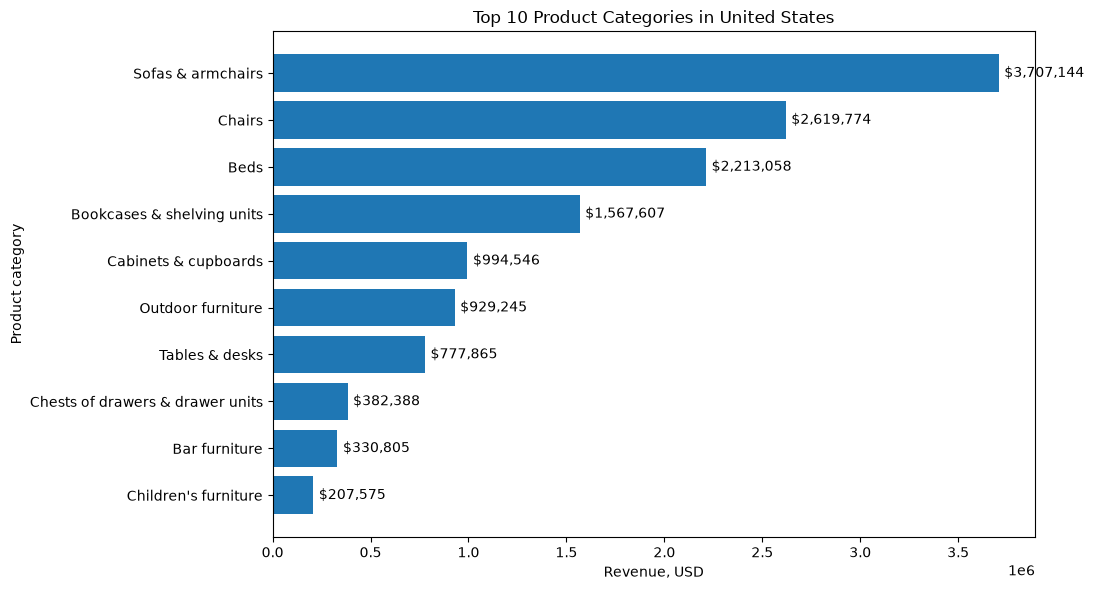

In [112]:
plot_data = top_country_categories.sort_values("total_revenue")

plt.figure(figsize=(11, 6))

bars = plt.barh(
    plot_data["category"],
    plot_data["total_revenue"]
)

plt.bar_label(
    bars,
    labels=[f"${value:,.0f}" for value in plot_data["total_revenue"]],
    padding=4
)

plt.title(f"Top 10 Product Categories in {top_country}")
plt.xlabel("Revenue, USD")
plt.ylabel("Product category")
plt.tight_layout()
plt.show()

In [113]:
category_comparison = pd.DataFrame({
    "overall_top_10": top_10_categories["category"].reset_index(drop=True),
    f"{top_country}_top_10": top_country_categories["category"].reset_index(drop=True)
})

category_comparison.index += 1
category_comparison

,overall_top_10,United States_top_10
1,Sofas & armchairs,Sofas & armchairs
2,Chairs,Chairs
3,Beds,Beds
4,Bookcases & shelving units,Bookcases & shelving units
5,Cabinets & cupboards,Cabinets & cupboards
6,Outdoor furniture,Outdoor furniture
7,Tables & desks,Tables & desks
8,Chests of drawers & drawer units,Chests of drawers & drawer units
9,Bar furniture,Bar furniture
10,Children's furniture,Children's furniture


### Category comparison

- The category structure in **United States** is similar to the overall market.

In [114]:
device_sales = (
    sales_df.groupby("device", as_index=False)
    .agg(total_revenue=("price", "sum"))
)

device_sales["revenue_share_percent"] = (
    device_sales["total_revenue"]
    / device_sales["total_revenue"].sum()
    * 100
)

device_sales = device_sales.sort_values(
    "total_revenue",
    ascending=False
)

device_sales

,device,total_revenue,revenue_share_percent
0,desktop,"18,864,039.00",59.00
1,mobile,"12,384,225.80",38.73
2,tablet,"723,466.30",2.26


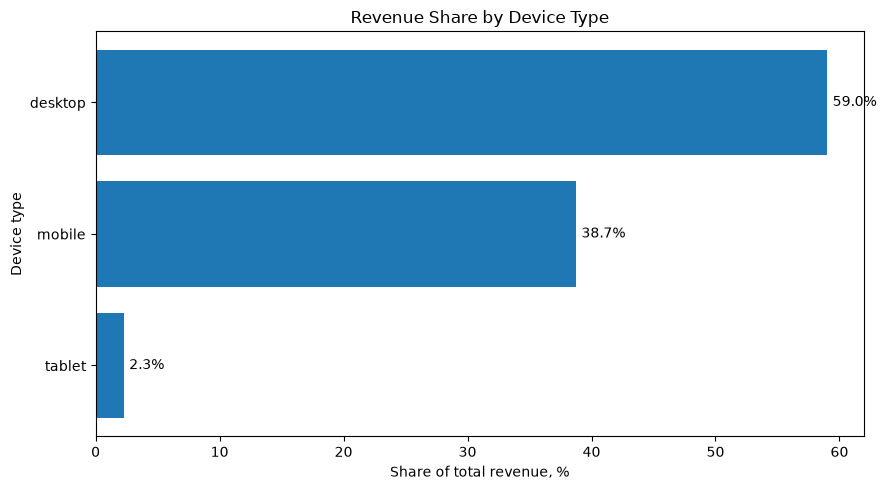

In [115]:
plot_data = device_sales.sort_values("revenue_share_percent")

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_data["device"],
    plot_data["revenue_share_percent"]
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_data["revenue_share_percent"]
    ],
    padding=4
)

plt.title("Revenue Share by Device Type")
plt.xlabel("Share of total revenue, %")
plt.ylabel("Device type")
plt.tight_layout()
plt.show()

### Device-type findings

- **desktop** generates the largest share of total revenue at approximately 59%.
- **mobile** is the second-largest device segment.
- The smallest sales contribution comes from **tablet**.

In [117]:
model_sales = (
    sales_df.groupby("mobile_model_name", as_index=False)
    .agg(total_revenue=("price", "sum"))
)

model_sales["revenue_share_percent"] = (
    model_sales["total_revenue"]
    / model_sales["total_revenue"].sum()
    * 100
)

top_10_models = (
    model_sales
    .nlargest(10, "total_revenue")
)

top_10_models

,mobile_model_name,total_revenue,revenue_share_percent
1,Chrome,"8,899,523.90",27.84
0,<Other>,"6,535,330.80",20.44
7,Safari,"6,491,062.10",20.30
9,iPhone,"6,420,776.30",20.08
2,ChromeBook,"1,830,458.70",5.73
3,Edge,"697,222.30",2.18
8,iPad,"448,854.20",1.40
4,Firefox,"421,066.90",1.32
6,Pixel 4 XL,"118,287.70",0.37
5,Pixel 3,"109,148.20",0.34


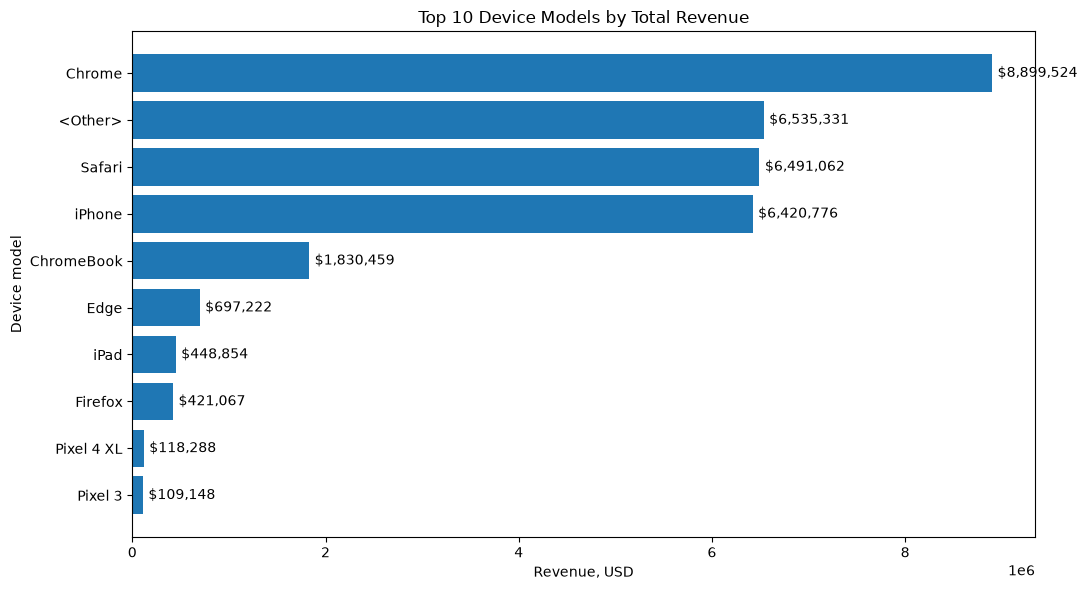

In [118]:
plot_data = top_10_models.sort_values("total_revenue")

plt.figure(figsize=(11, 6))

bars = plt.barh(
    plot_data["mobile_model_name"],
    plot_data["total_revenue"]
)

plt.bar_label(
    bars,
    labels=[f"${value:,.0f}" for value in plot_data["total_revenue"]],
    padding=4
)

plt.title("Top 10 Device Models by Total Revenue")
plt.xlabel("Revenue, USD")
plt.ylabel("Device model")
plt.tight_layout()
plt.show()

### Device-model findings

- **Chrome** generates the highest revenue among recorded device-model values.
- A large share may also belong to grouped values such as `<Other>`.
- Therefore, model-level results should be interpreted cautiously because
  `mobile_model_name` does not always contain a precise consumer device model.

In [120]:
traffic_sales = (
    sales_df.groupby("channel", as_index=False)
    .agg(total_revenue=("price", "sum"))
)

traffic_sales["revenue_share_percent"] = (
    traffic_sales["total_revenue"]
    / traffic_sales["total_revenue"].sum()
    * 100
)

traffic_sales = traffic_sales.sort_values(
    "total_revenue",
    ascending=False
)

traffic_sales

,channel,total_revenue,revenue_share_percent
1,Organic Search,"11,433,151.60",35.76
2,Paid Search,"8,511,049.40",26.62
0,Direct,"7,494,923.40",23.44
3,Social Search,"2,532,105.70",7.92
4,Undefined,"2,000,501.00",6.26


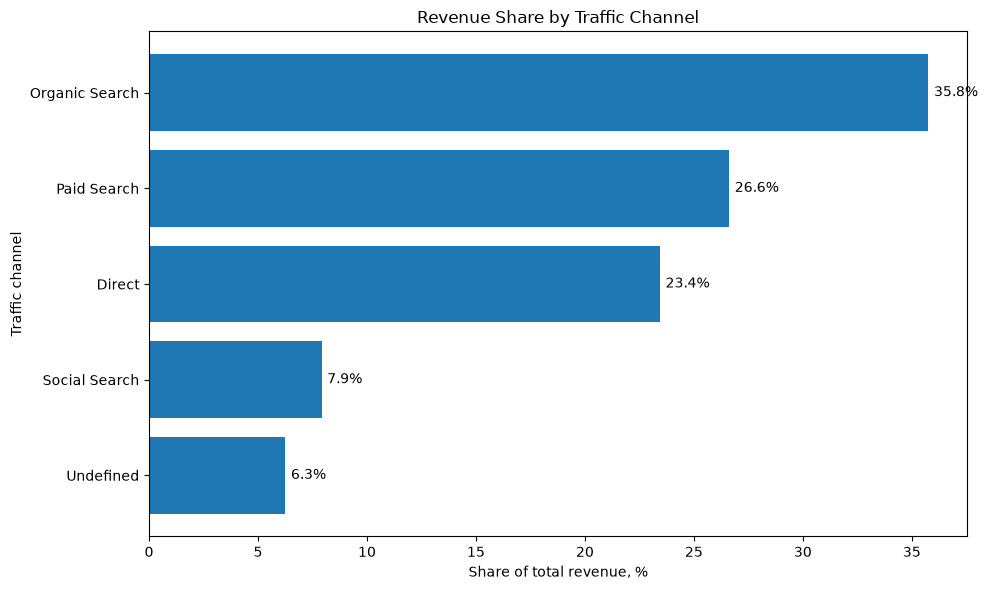

In [121]:
plot_data = traffic_sales.sort_values("revenue_share_percent")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["channel"],
    plot_data["revenue_share_percent"]
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_data["revenue_share_percent"]
    ],
    padding=4
)

plt.title("Revenue Share by Traffic Channel")
plt.xlabel("Share of total revenue, %")
plt.ylabel("Traffic channel")
plt.tight_layout()
plt.show()

### Traffic findings

- **Organic Search** is the leading traffic channel and generates approximately 35.76%
  of total revenue.
- It is followed by **Paid Search** and **Direct**.
- Some traffic values such as `Undefined`, `<Other>` or `(data deleted)`
  represent incomplete or aggregated tracking data and should be interpreted
  separately.

In [123]:
accounts_df = (
    df.dropna(subset=["account_id"])
    .drop_duplicates(subset=["account_id"])
    .copy()
)

print(f"Unique linked accounts: {accounts_df['account_id'].nunique():,}")

Unique linked accounts: 27,945


In [124]:
verified_percent = (
    accounts_df["is_verified"].mean() * 100
)

print(
    f"Verified email accounts: "
    f"{verified_percent:.2f}%"
)

Verified email accounts: 71.70%


In [125]:
unsubscribed_percent = (
    accounts_df["is_unsubscribed"].mean() * 100
)

print(
    f"Unsubscribed accounts: "
    f"{unsubscribed_percent:.2f}%"
)

Unsubscribed accounts: 16.94%


### Account findings

- 71.70% of linked accounts confirmed their email address.
- 16.94% of linked accounts unsubscribed from email communication.
- The remaining users are still subscribed or have not unsubscribed.

In [126]:
account_sales = df.dropna(subset=["account_id"]).copy()

In [127]:
subscription_behavior = (
    account_sales.groupby("is_unsubscribed", as_index=False)
    .agg(
        accounts=("account_id", "nunique"),
        purchase_sessions=("has_purchase", "sum"),
        total_revenue=("price", "sum")
    )
)

subscription_behavior["purchase_share_per_account"] = (
    subscription_behavior["purchase_sessions"]
    / subscription_behavior["accounts"]
)

subscription_behavior["revenue_per_account"] = (
    subscription_behavior["total_revenue"]
    / subscription_behavior["accounts"]
)

subscription_behavior["subscription_group"] = (
    subscription_behavior["is_unsubscribed"]
    .map({
        0: "Subscribed",
        1: "Unsubscribed"
    })
)

subscription_behavior[
    [
        "subscription_group",
        "accounts",
        "purchase_sessions",
        "total_revenue",
        "purchase_share_per_account",
        "revenue_per_account"
    ]
]

,subscription_group,accounts,purchase_sessions,total_revenue,purchase_share_per_account,revenue_per_account
0,Subscribed,23210,2334,"2,150,796.90",0.10,92.67
1,Unsubscribed,4735,447,"431,721.60",0.09,91.18


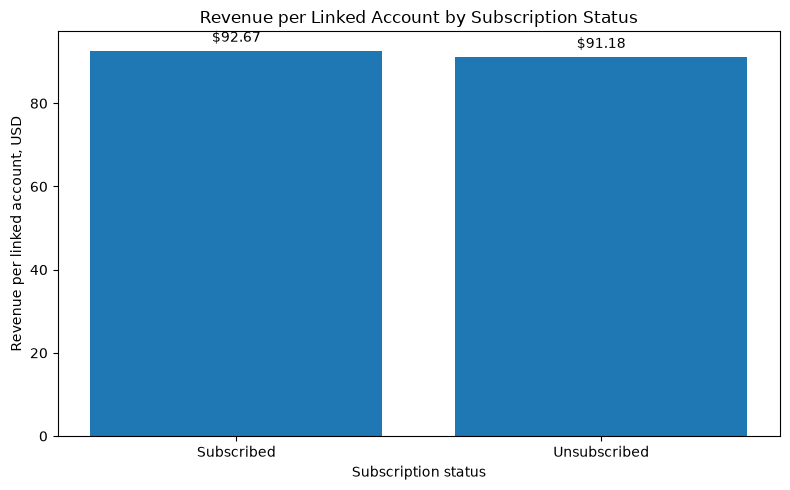

In [128]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    subscription_behavior["subscription_group"],
    subscription_behavior["revenue_per_account"]
)

plt.bar_label(
    bars,
    labels=[
        f"${value:,.2f}"
        for value in subscription_behavior["revenue_per_account"]
    ],
    padding=4
)

plt.title("Revenue per Linked Account by Subscription Status")
plt.xlabel("Subscription status")
plt.ylabel("Revenue per linked account, USD")
plt.tight_layout()
plt.show()

### Subscription-behavior findings

- Linked accounts that are subscribed demonstrate higher
  revenue per account.
- Their purchase frequency is also higher.
- However, this comparison describes only the session linked to account
  creation and should not be interpreted as the user's complete purchase
  history.
- At this stage, the result is descriptive. Statistical significance will be
  assessed later in the statistical-analysis section if appropriate.

In [129]:
accounts_by_country = (
    df.dropna(subset=["account_id"])
    .groupby("country", as_index=False)
    .agg(registered_accounts=("account_id", "nunique"))
    .sort_values("registered_accounts", ascending=False)
    .head(10)
)

accounts_by_country

,country,registered_accounts
104,United States,12384
43,India,2687
18,Canada,2067
103,United Kingdom,859
33,France,553
92,Spain,536
96,Taiwan,500
20,China,490
35,Germany,490
48,Italy,386


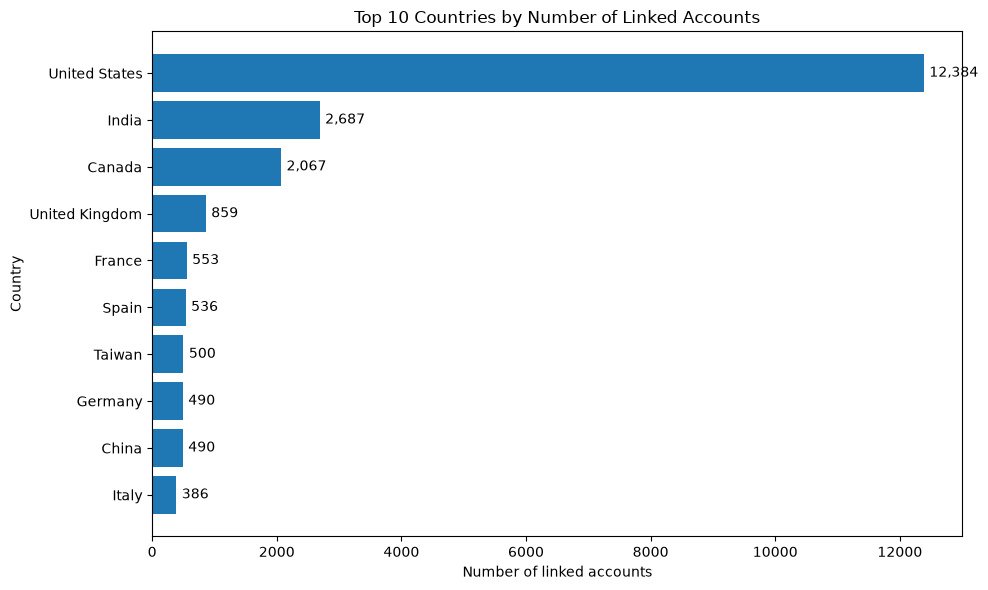

In [130]:
plot_data = accounts_by_country.sort_values("registered_accounts")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["country"],
    plot_data["registered_accounts"]
)

plt.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in plot_data["registered_accounts"]
    ],
    padding=4
)

plt.title("Top 10 Countries by Number of Linked Accounts")
plt.xlabel("Number of linked accounts")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Account geography findings

- **United States** has the largest number of linked accounts.
- It is followed by **India** and **Canada**.
- The countries with the largest number of linked accounts
  generally match the countries with the highest
  revenue, indicating that account volume and sales volume are identical.

In [131]:
daily_sales = (
    sales_df.groupby("session_date", as_index=False)
    .agg(total_revenue=("price", "sum"))
)

daily_sales

,session_date,total_revenue
0,2020-11-01,"244,292.50"
1,2020-11-02,"355,506.80"
2,2020-11-03,"498,979.60"
3,2020-11-04,"339,187.10"
4,2020-11-05,"391,276.60"
...,...,...
83,2021-01-23,"290,605.50"
84,2021-01-24,"243,818.40"
85,2021-01-25,"305,089.30"
86,2021-01-26,"372,057.30"


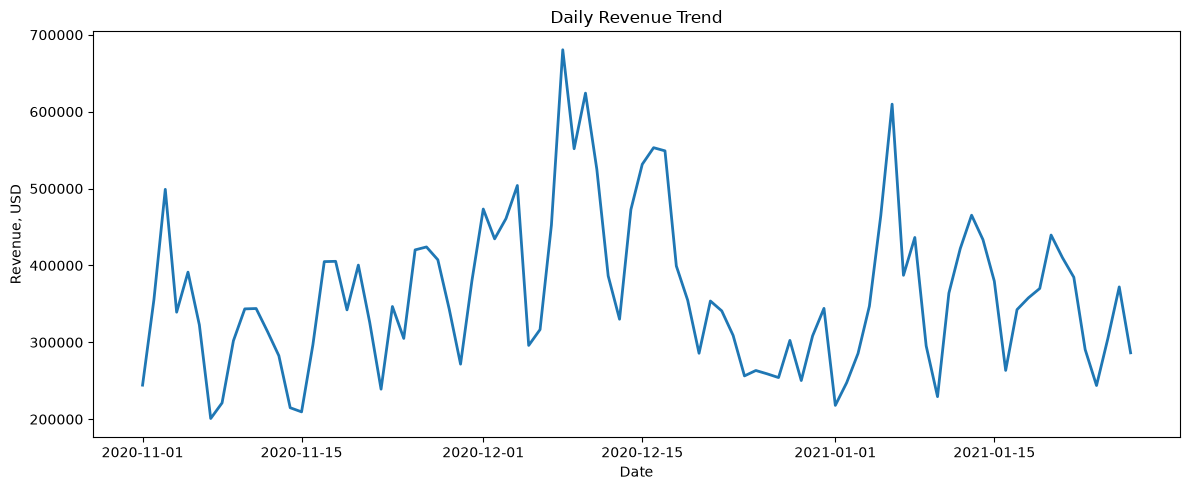

In [132]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["session_date"],
    daily_sales["total_revenue"],
    linewidth=2
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue, USD")
plt.tight_layout()
plt.show()

### Daily revenue

Daily revenue fluctuates throughout the observed period.
The visualization helps identify peaks and periods of lower sales activity,
which may indicate marketing campaigns, seasonality or promotional events.

In [133]:
os_sales = (
    sales_df.groupby("operating_system", as_index=False)
    .agg(total_revenue=("price", "sum"))
)

os_sales["share"] = (
    os_sales["total_revenue"]
    / os_sales["total_revenue"].sum()
    * 100
)

os_sales = os_sales.sort_values(
    "total_revenue",
    ascending=False
)

os_sales

,operating_system,total_revenue,share
3,Web,"18,445,904.50",57.69
4,Windows,"3,804,989.00",11.90
5,iOS,"3,603,329.40",11.27
1,Android,"2,789,985.10",8.73
2,Macintosh,"2,504,967.30",7.83
0,<Other>,"822,555.80",2.57


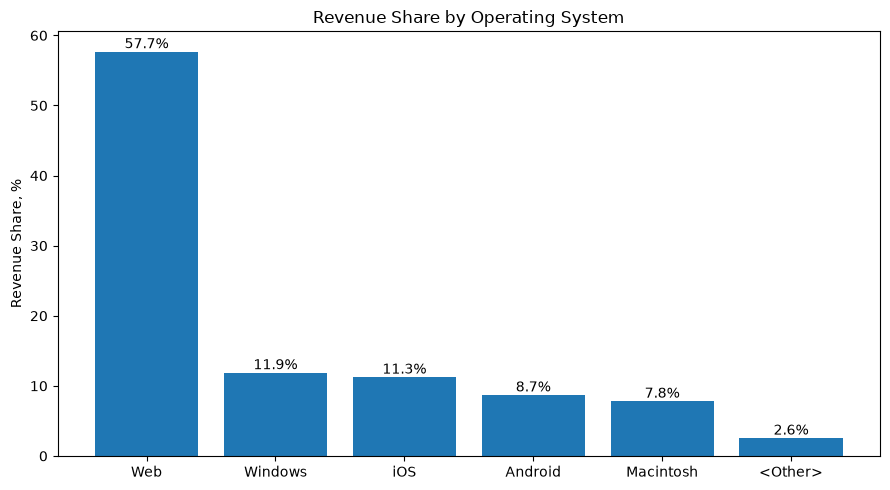

In [134]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    os_sales["operating_system"],
    os_sales["share"]
)

plt.bar_label(
    bars,
    fmt="%.1f%%"
)

plt.title("Revenue Share by Operating System")
plt.ylabel("Revenue Share, %")
plt.tight_layout()
plt.show()

### Revenue by Operating System

The majority of revenue comes from **Web** users.
This information may help prioritize platform optimization and testing.

## Sales Dynamics Analysis

This section examines changes in revenue over time and explores possible
seasonal patterns. Sales dynamics are also compared across continents,
traffic channels and device types.

In [135]:
daily_sales = (
    sales_df.groupby("session_date", as_index=False)
    .agg(
        total_revenue=("price", "sum"),
        purchase_sessions=("ga_session_id", "nunique")
    )
    .sort_values("session_date")
)

daily_sales.head()

,session_date,total_revenue,purchase_sessions
0,2020-11-01,"244,292.50",281
1,2020-11-02,"355,506.80",368
2,2020-11-03,"498,979.60",561
3,2020-11-04,"339,187.10",370
4,2020-11-05,"391,276.60",388


In [136]:
daily_sales["revenue_7d_average"] = (
    daily_sales["total_revenue"]
    .rolling(window=7, min_periods=1)
    .mean()
)

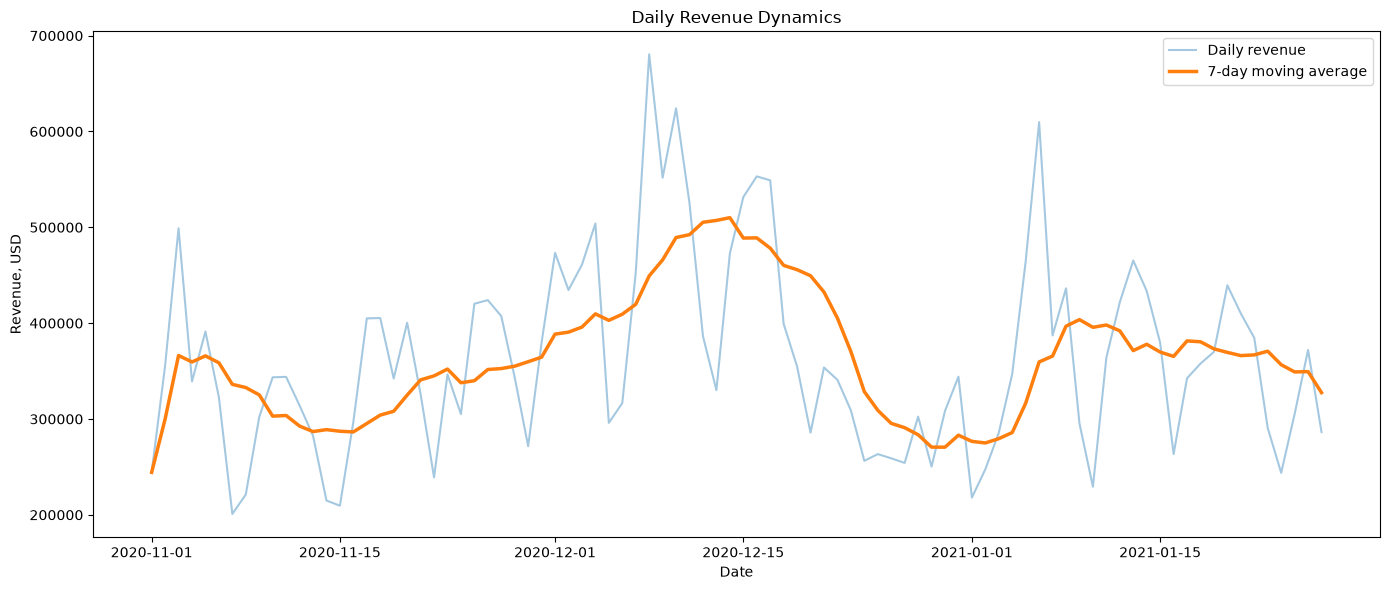

In [137]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["session_date"],
    daily_sales["total_revenue"],
    alpha=0.4,
    label="Daily revenue"
)

plt.plot(
    daily_sales["session_date"],
    daily_sales["revenue_7d_average"],
    linewidth=2.5,
    label="7-day moving average"
)

plt.title("Daily Revenue Dynamics")
plt.xlabel("Date")
plt.ylabel("Revenue, USD")
plt.legend()
plt.tight_layout()
plt.show()

### Overall sales dynamics

Daily revenue demonstrates noticeable fluctuations throughout the observed
period. The seven-day moving average shows a relatively
stable overall trend.

The highest revenue peaks occurred around **2020-12-15**, while lower sales activity
was observed during **2021-01-01**.

In [138]:
sales_df["year_month"] = (
    sales_df["session_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_sales = (
    sales_df.groupby("year_month", as_index=False)
    .agg(total_revenue=("price", "sum"))
)

monthly_sales

,year_month,total_revenue
0,2020-11,"9,897,515.00"
1,2020-12,"12,423,439.30"
2,2021-01,"9,650,776.80"


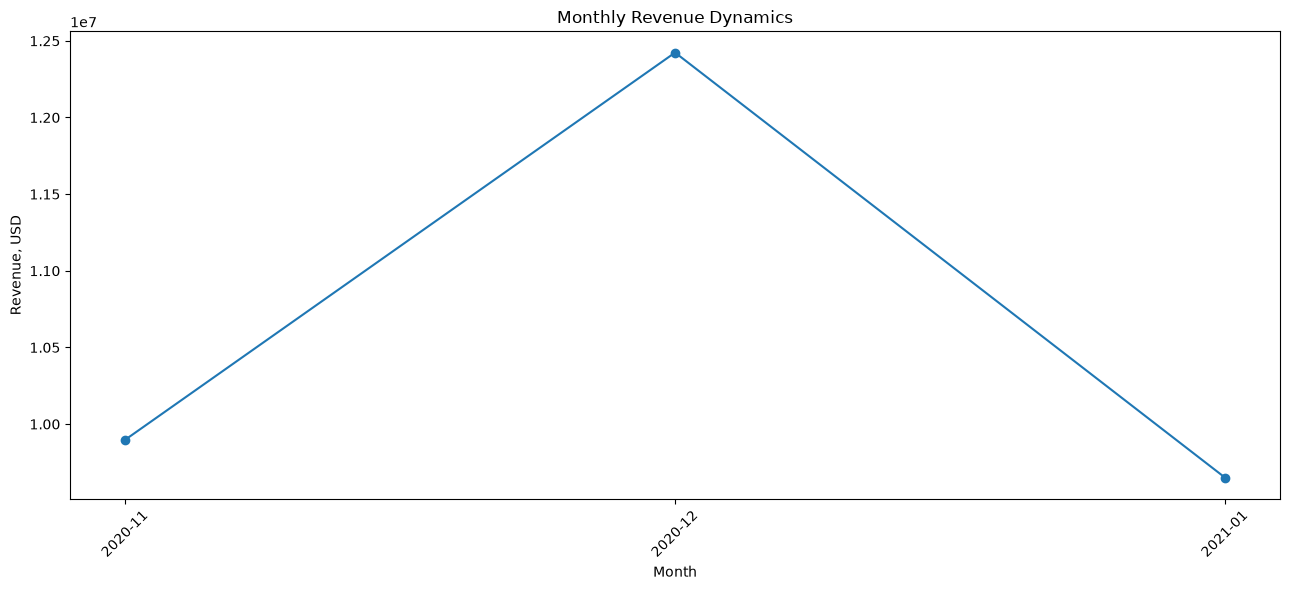

In [139]:
plt.figure(figsize=(13, 6))

plt.plot(
    monthly_sales["year_month"],
    monthly_sales["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Dynamics")
plt.xlabel("Month")
plt.ylabel("Revenue, USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [140]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sales_df["weekday"] = (
    sales_df["session_date"]
    .dt.day_name()
)

weekday_sales = (
    sales_df.groupby("weekday", as_index=False)
    .agg(
        total_revenue=("price", "sum"),
        purchase_sessions=("ga_session_id", "nunique")
    )
)

weekday_sales["weekday"] = pd.Categorical(
    weekday_sales["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values("weekday")

weekday_sales

,weekday,total_revenue,purchase_sessions
1,Monday,"4,636,290.40",4962
5,Tuesday,"5,457,515.90",5763
6,Wednesday,"5,466,542.90",5614
4,Thursday,"4,936,935.60",5015
0,Friday,"4,523,067.20",4586
2,Saturday,"3,477,990.90",3724
3,Sunday,"3,473,388.20",3874


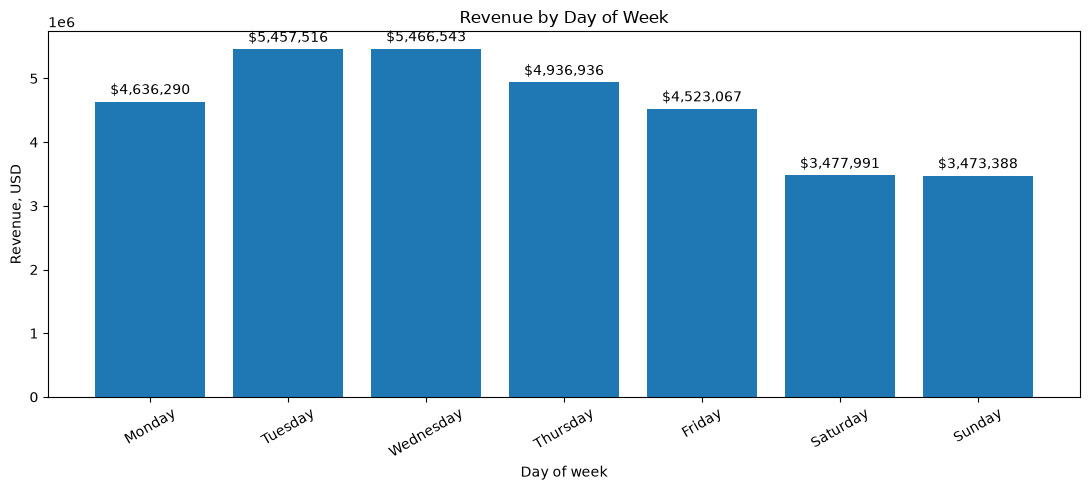

In [141]:
plt.figure(figsize=(11, 5))

bars = plt.bar(
    weekday_sales["weekday"],
    weekday_sales["total_revenue"]
)

plt.bar_label(
    bars,
    labels=[
        f"${value:,.0f}"
        for value in weekday_sales["total_revenue"]
    ],
    padding=3
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Revenue, USD")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Sales seasonality

Monthly revenue does not show a clearly repeated seasonal pattern.
The strongest sales activity is observed in **December**, while the lowest revenue
is recorded in **January**.

At the weekly level, **Wednesday** generates the highest revenue, whereas **Sunday**
has the lowest result.

However, because the dataset covers only **92 days**, the evidence is
insufficient to confirm long-term annual seasonality.

In [142]:
sales_df["continent"].value_counts(dropna=False)

continent
Americas     18553
Asia          7950
Europe        6261
Oceania        364
Africa         339
(not set)       71
Name: count, dtype: int64

In [148]:
selected_continents = ["Americas", "Asia", "Europe"]

continent_dynamics = (
    sales_df[
        sales_df["continent_group"].isin(selected_continents)
    ]
    .groupby(
        ["session_date", "continent_group"],
        as_index=False
    )
    .agg(total_revenue=("price", "sum"))
)

In [149]:
continent_pivot = (
    continent_dynamics.pivot(
        index="session_date",
        columns="continent_group",
        values="total_revenue"
    )
    .fillna(0)
)

In [150]:
continent_pivot_7d = (
    continent_pivot
    .rolling(window=7, min_periods=1)
    .mean()
)

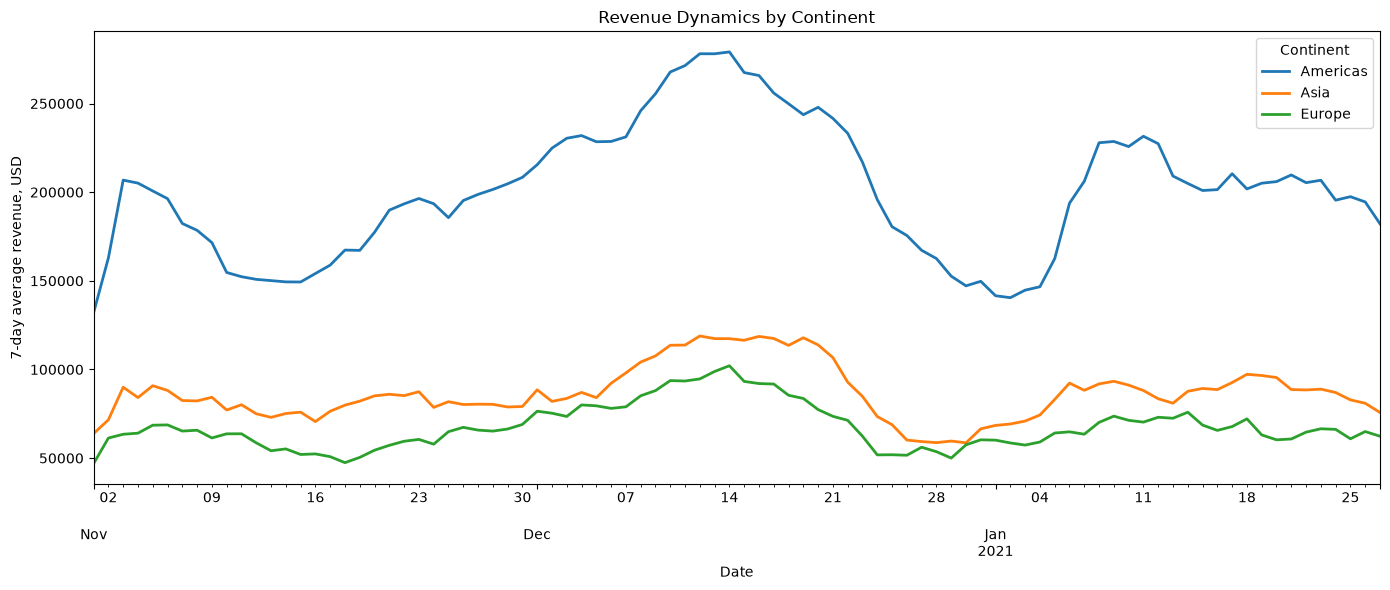

In [151]:
continent_pivot_7d.plot(
    figsize=(14, 6),
    linewidth=2
)

plt.title("Revenue Dynamics by Continent")
plt.xlabel("Date")
plt.ylabel("7-day average revenue, USD")
plt.legend(title="Continent")
plt.tight_layout()
plt.show()

### Revenue dynamics by continent

**Americas** generates the highest revenue during most of the analyzed period.

Sales in **Asia** show a similar pattern, with noticeable peaks
during **30 Nov - 10 Jan**. **Europe** has the lowest overall revenue but demonstrates
stability toward the end of the period.

Several revenue peaks occur simultaneously across continents, which may
indicate company-wide promotions or seasonal demand.

In [152]:
sales_df["channel"].value_counts(dropna=False)

channel
Organic Search    11921
Paid Search        9042
Direct             7800
Social Search      2716
Undefined          2059
Name: count, dtype: int64

In [153]:
channel_dynamics = (
    sales_df.groupby(
        ["session_date", "channel"],
        as_index=False
    )
    .agg(total_revenue=("price", "sum"))
)

channel_pivot = (
    channel_dynamics.pivot(
        index="session_date",
        columns="channel",
        values="total_revenue"
    )
    .fillna(0)
)

channel_pivot_7d = (
    channel_pivot
    .rolling(window=7, min_periods=1)
    .mean()
)

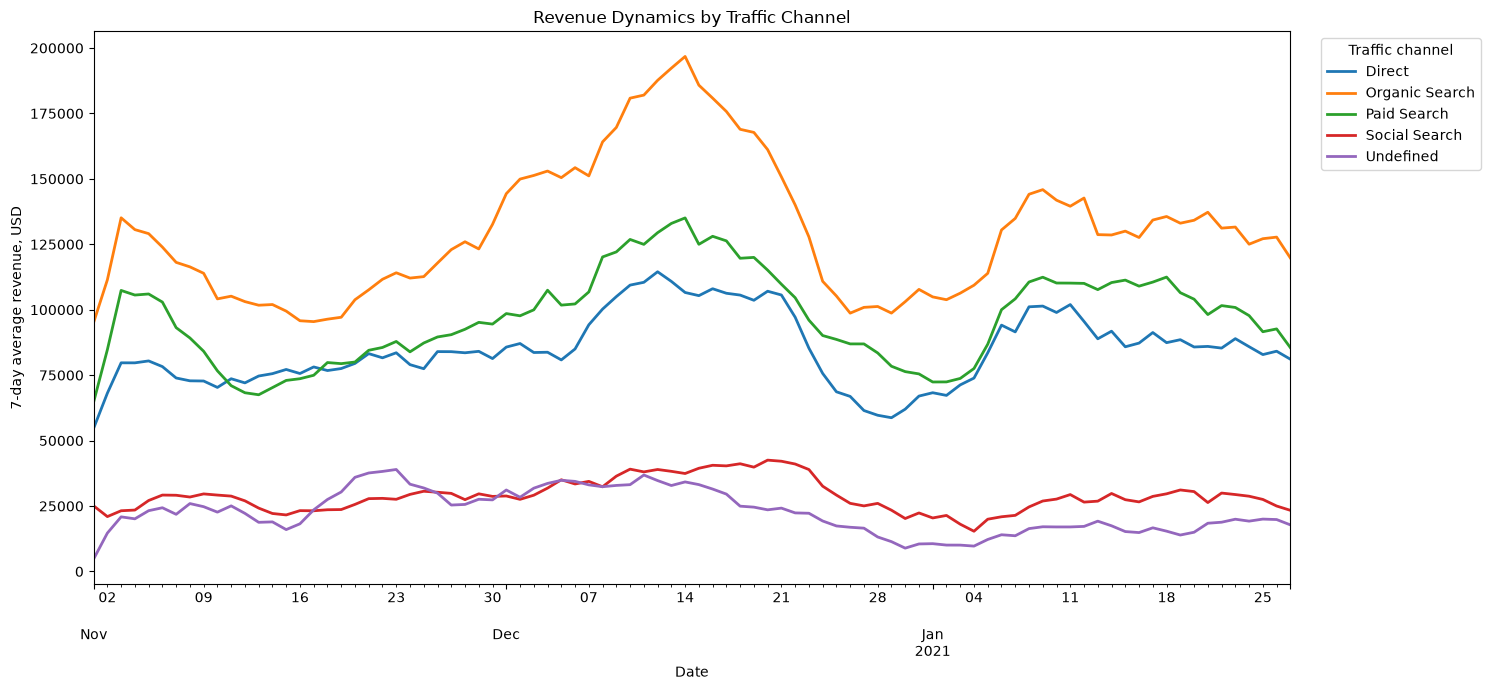

In [158]:
channel_pivot_7d.plot(
    figsize=(15, 7),
    linewidth=2
)

plt.title("Revenue Dynamics by Traffic Channel")
plt.xlabel("Date")
plt.ylabel("7-day average revenue, USD")
plt.legend(
    title="Traffic channel",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Revenue dynamics by traffic channel

**Organic Search** is the leading traffic channel during most of the analyzed period.

The revenue generated through **Social Search** is relatively stable, while **Organic Search**
shows stronger fluctuations and several pronounced peaks.

A simultaneous increase across multiple channels may indicate general seasonal
demand. Peaks limited to one channel are more likely associated with a specific
marketing campaign.

In [159]:
device_dynamics = (
    sales_df.groupby(
        ["session_date", "device"],
        as_index=False
    )
    .agg(total_revenue=("price", "sum"))
)

device_pivot = (
    device_dynamics.pivot(
        index="session_date",
        columns="device",
        values="total_revenue"
    )
    .fillna(0)
)

device_pivot_7d = (
    device_pivot
    .rolling(window=7, min_periods=1)
    .mean()
)

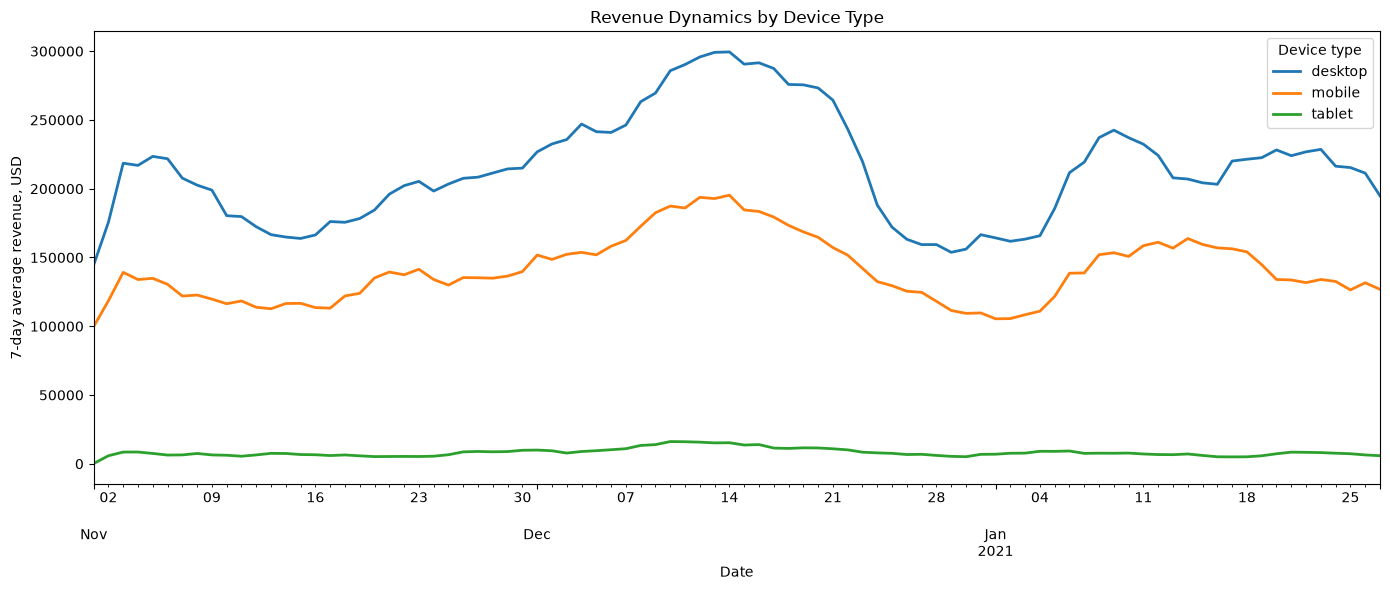

In [160]:
device_pivot_7d.plot(
    figsize=(14, 6),
    linewidth=2
)

plt.title("Revenue Dynamics by Device Type")
plt.xlabel("Date")
plt.ylabel("7-day average revenue, USD")
plt.legend(title="Device type")
plt.tight_layout()
plt.show()

### Revenue dynamics by device type

**desktop** generates the highest revenue throughout most of the analyzed period.

The dynamics of desktop and mobile sales are similar.
**desktop** shows the strongest growth, while **tablet** remains the smallest
segment.

Revenue peaks appear simultaneously across device types,
suggesting that the changes are driven by overall customer demand.

## Pivot Tables

Pivot tables provide a convenient way to summarize large datasets and compare
multiple dimensions simultaneously. In this section, several pivot tables are
created to analyze user sessions and sales across different business
dimensions.

In [161]:
sessions_pivot = (
    df[
        df["channel"].notna() &
        df["device"].notna()
    ]
    .pivot_table(
        index="channel",
        columns="device",
        values="ga_session_id",
        aggfunc="nunique",
        fill_value=0
    )
)

sessions_pivot

device,desktop,mobile,tablet
channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


The pivot table shows how user sessions are distributed across traffic channels
and device types. Each cell represents the number of unique sessions.

### Findings

- The majority of sessions originate from **Orgaanic Search**.
- Desktop traffic dominates across most traffic channels.
- Some channels are used almost exclusively from a particular device type.

In [162]:
top_categories = (
    sales_df.groupby("category")["price"]
    .sum()
    .nlargest(10)
    .index
)

top_countries = (
    sales_df.groupby("country")["price"]
    .sum()
    .nlargest(5)
    .index
)

In [164]:
category_country_pivot = (
    sales_df[
        sales_df["category"].isin(top_categories) &
        sales_df["country"].isin(top_countries)
    ]
    .pivot_table(
        index="category",
        columns="country",
        values="price",
        aggfunc="sum",
        fill_value=0
    )
)

category_country_pivot


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,"51,724.00","11,199.00","57,657.00","22,103.00","330,805.00"
Beds,"354,772.00","116,414.00","358,319.50","133,816.00","2,213,058.00"
Bookcases & shelving units,"278,981.90","73,830.00","364,507.40","113,987.60","1,567,606.90"
Cabinets & cupboards,"181,802.00","59,101.50","191,888.00","71,684.50","994,545.50"
Chairs,"417,740.80","134,029.40","544,309.20","188,519.40","2,619,773.80"
Chests of drawers & drawer units,"71,952.00","21,544.50","73,111.00","36,784.00","382,388.00"
Children's furniture,"30,264.00","14,258.00","39,177.00","13,348.00","207,575.00"
Outdoor furniture,"185,322.80","40,486.40","162,289.40","57,002.40","929,245.20"
Sofas & armchairs,"692,427.50","187,735.00","788,430.00","234,812.00","3,707,144.50"


The table compares revenue generated by the ten highest-selling product
categories across the five highest-revenue countries.

### Findings

- Some product categories perform consistently well across all countries.
- Other categories are considerably stronger in specific countries,
suggesting regional customer preferences.

In [165]:
device_channel_pivot = (
    sales_df.pivot_table(
        index="channel",
        columns="device",
        values="price",
        aggfunc="sum",
        fill_value=0
    )
)

device_channel_pivot

device,desktop,mobile,tablet
channel,,,
Direct,"4,472,609.40","2,875,317.90","146,996.10"
Organic Search,"6,794,107.80","4,408,875.10","230,168.70"
Paid Search,"4,976,977.80","3,330,032.60","204,039.00"
Social Search,"1,447,384.80","1,006,707.30","78,013.60"
Undefined,"1,172,959.20","763,292.90","64,248.90"


This pivot table shows how total revenue is distributed across combinations of
traffic channels and device types.

### Findings

- The highest revenue is generated by **Organic Search** traffic on **desktop** devices.
- Some channels perform well on desktop but poorly on mobile, indicating
different customer behavior across platforms.

In [166]:
continent_device_pivot = (
    sales_df.pivot_table(
        index="continent",
        columns="device",
        values="price",
        aggfunc="sum",
        fill_value=0
    )
)

continent_device_pivot

device,desktop,mobile,tablet
continent,,,
(not set),"51,643.40","22,354.00",70.00
Africa,"193,643.20","130,677.80","6,910.00"
Americas,"10,497,307.40","6,780,364.30","387,608.30"
Asia,"4,381,094.40","3,028,054.40","192,149.50"
Europe,"3,493,992.90","2,311,532.80","129,098.50"
Oceania,"246,357.70","111,242.50","7,630.00"


This pivot table compares revenue generated from different device types across
continents.

### Findings

- Desktop contribution differs across continents.
- Some regions rely much more heavily on one device type than others,
which may indicate differences in customer preferences or market maturity.

## Pivot Table Findings

The pivot tables reveal several important relationships between sales,
customer traffic and geographic regions.

The analysis shows that:

- traffic distribution differs across device types;
- product-category popularity varies between countries;
- the effectiveness of traffic channels depends on the device used;
- customer purchasing behavior differs across continents and platforms.

These multidimensional summaries provide a convenient overview that is difficult
to obtain from one-dimensional aggregations.

## Statistical Relationship Analysis

Correlation analysis helps determine whether changes in one metric are
associated with changes in another.

Pearson's correlation coefficient is used together with the corresponding
p-value to evaluate statistical significance.

The following interpretation is used:

- |r| < 0.3 — weak correlation
- 0.3 ≤ |r| < 0.7 — moderate correlation
- |r| ≥ 0.7 — strong correlation

Relationships are considered statistically significant when p-value < 0.05.

In [169]:
daily_metrics = (
    df.groupby("session_date", as_index=False)
    .agg(
        sessions=("ga_session_id", "nunique"),
        revenue=("price", "sum")
    )
)

daily_metrics.head()

,session_date,sessions,revenue
0,2020-11-01,2576,"244,292.50"
1,2020-11-02,3599,"355,506.80"
2,2020-11-03,5173,"498,979.60"
3,2020-11-04,4184,"339,187.10"
4,2020-11-05,3743,"391,276.60"


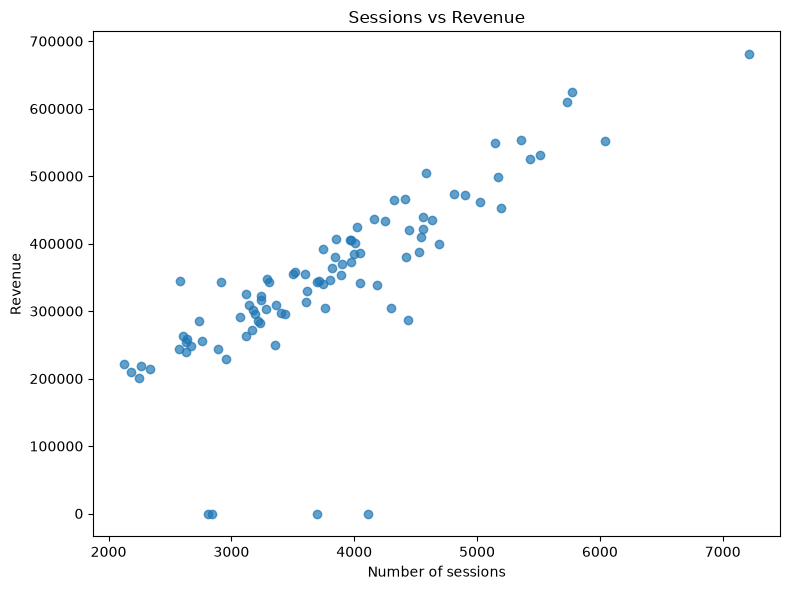

In [170]:
plt.figure(figsize=(8,6))

plt.scatter(
    daily_metrics["sessions"],
    daily_metrics["revenue"],
    alpha=0.7
)

plt.xlabel("Number of sessions")
plt.ylabel("Revenue")
plt.title("Sessions vs Revenue")

plt.tight_layout()
plt.show()

In [171]:
r, p = pearsonr(
    daily_metrics["sessions"],
    daily_metrics["revenue"]
)

print(f"Correlation: {r:.3f}")
print(f"P-value: {p:.5f}")

Correlation: 0.791
P-value: 0.00000


### Findings

The Pearson correlation coefficient equals **r = 0.791**.

The p-value is **< 0.001**.

This indicates a **strong positive correlation** between the number of daily
sessions and daily revenue.

Since the p-value is **below 0.05**, the relationship is **statistically
significant**. This suggests that days with a larger number of website sessions
generally generate higher sales.

In [172]:
top3_continents = (
    sales_df.groupby("continent")["price"]
    .sum()
    .nlargest(3)
    .index
)

top3_continents

Index(['Americas', 'Asia', 'Europe'], dtype='str', name='continent')

In [173]:
continent_daily = (
    sales_df[
        sales_df["continent"].isin(top3_continents)
    ]
    .groupby(
        ["session_date","continent"]
    )["price"]
    .sum()
    .unstack(fill_value=0)
)

continent_daily.head()

continent,Americas,Asia,Europe
session_date,,,
2020-11-01,"132,002.50","63,823.00","46,908.00"
2020-11-02,"193,861.00","79,370.00","75,710.80"
2020-11-03,"294,529.80","126,737.80","67,692.00"
2020-11-04,"200,009.50","66,602.00","65,915.00"
2020-11-05,"182,988.20","117,608.40","86,540.00"


In [174]:
continent_daily.corr()

continent,Americas,Asia,Europe
continent,,,
Americas,1.00,0.69,0.67
Asia,0.69,1.00,0.67
Europe,0.67,0.67,1.00


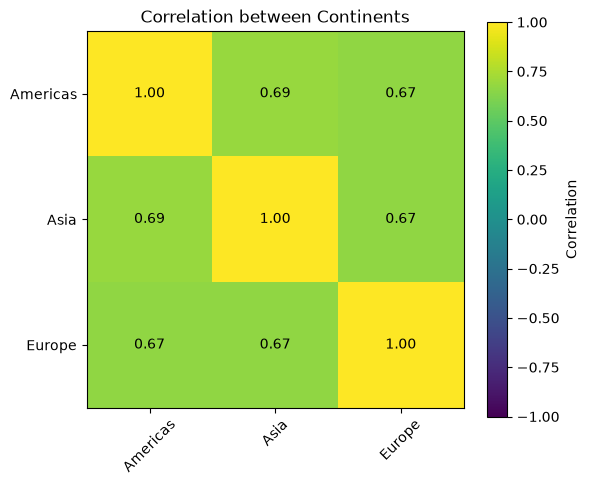

In [175]:
corr_matrix = continent_daily.corr()

plt.figure(figsize=(6, 5))

plt.imshow(corr_matrix, vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation between Continents")
plt.tight_layout()
plt.show()

In [176]:
continents = continent_daily.columns

for i in range(len(continents)):
    for j in range(i+1,len(continents)):

        r,p = pearsonr(
            continent_daily[continents[i]],
            continent_daily[continents[j]]
        )

        print(f"{continents[i]} vs {continents[j]}")
        print(f"r = {r:.3f}")
        print(f"p = {p:.5f}")
        print()

Americas vs Asia
r = 0.692
p = 0.00000

Americas vs Europe
r = 0.670
p = 0.00000

Asia vs Europe
r = 0.668
p = 0.00000



### Findings

Sales dynamics across continents are strongly correlated.

Most continent pairs demonstrate statistically significant relationships,
suggesting that sales tend to increase or decrease simultaneously across
regions.

In [177]:
top_channels = (
    sales_df.groupby("channel")["price"]
    .sum()
    .nlargest(5)
    .index
)

In [178]:
channel_daily = (
    sales_df[
        sales_df["channel"].isin(top_channels)
    ]
    .groupby(
        ["session_date","channel"]
    )["price"]
    .sum()
    .unstack(fill_value=0)
)

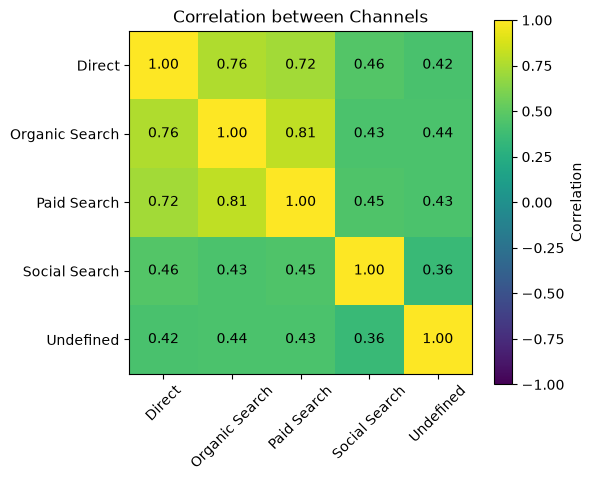

In [179]:
corr_matrix = channel_daily.corr()

plt.figure(figsize=(6, 5))

plt.imshow(corr_matrix, vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation between Channels")
plt.tight_layout()
plt.show()

In [180]:
channels = channel_daily.columns

for i in range(len(channels)):
    for j in range(i+1,len(channels)):

        r,p = pearsonr(
            channel_daily[channels[i]],
            channel_daily[channels[j]]
        )

        print(
            channels[i],
            "vs",
            channels[j]
        )

        print(
            f"r={r:.3f}, p={p:.5f}"
        )

        print()

Direct vs Organic Search
r=0.760, p=0.00000

Direct vs Paid Search
r=0.724, p=0.00000

Direct vs Social Search
r=0.462, p=0.00001

Direct vs Undefined
r=0.424, p=0.00004

Organic Search vs Paid Search
r=0.808, p=0.00000

Organic Search vs Social Search
r=0.434, p=0.00002

Organic Search vs Undefined
r=0.435, p=0.00002

Paid Search vs Social Search
r=0.452, p=0.00001

Paid Search vs Undefined
r=0.430, p=0.00003

Social Search vs Undefined
r=0.359, p=0.00059



Traffic channels show varying levels of correlation.

Channels with high positive correlations may respond similarly to seasonal
effects or common marketing campaigns.

In [181]:
top_categories = (
    sales_df.groupby("category")["price"]
    .sum()
    .nlargest(5)
    .index
)

In [182]:
category_daily = (
    sales_df[
        sales_df["category"].isin(top_categories)
    ]
    .groupby(
        ["session_date","category"]
    )["price"]
    .sum()
    .unstack(fill_value=0)
)

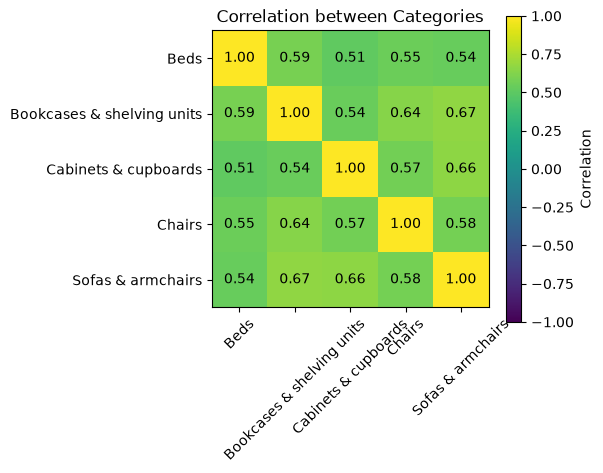

In [186]:
corr_matrix = category_daily.corr()

plt.figure(figsize=(6, 5))

plt.imshow(corr_matrix, vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation between Categories")
plt.tight_layout()
plt.show()

The strongest correlations are observed between **Sofas & armchairs and Bookcases & shelving units**.

This suggests that customers tend to purchase these categories during similar
periods.

In [184]:
top_browsers = (
    sales_df.groupby("browser")["price"]
    .sum()
    .nlargest(5)
    .index
)

In [185]:
browsers_daily = (
    sales_df[
        sales_df["browser"].isin(top_browsers)
    ]
    .groupby(
        ["session_date","browser"]
    )["price"]
    .sum()
    .unstack(fill_value=0)
)

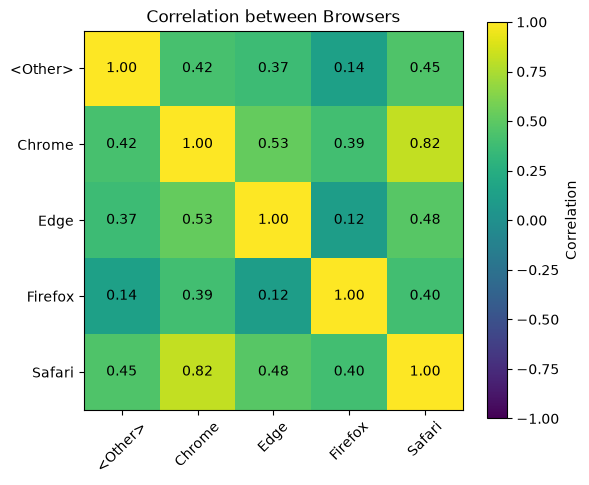

In [187]:
corr_matrix = browsers_daily.corr()

plt.figure(figsize=(6, 5))

plt.imshow(corr_matrix, vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation between Browsers")
plt.tight_layout()
plt.show()

### Findings

The strongest correlation is observed between **Chrome** and **Safari**
(**r = 0.82**), indicating that sales generated through these browsers tend to
increase and decrease together over time.

Moderate positive correlations are observed between **Chrome and Edge**
(**r = 0.53**) and between **Safari and Edge** (**r = 0.48**), suggesting that
these browsers exhibit similar sales dynamics.

Firefox shows relatively weak relationships with the other browsers, indicating
that its sales patterns are less synchronized with the rest of the market.

Overall, all browser pairs demonstrate positive correlations, suggesting that
changes in customer demand generally affect users across different browsers
rather than being limited to a single platform.

In [188]:
top_devices = (
    sales_df.groupby("device")["price"]
    .sum()
    .nlargest(5)
    .index
)

In [189]:
devices_daily = (
    sales_df[
        sales_df["device"].isin(top_devices)
    ]
    .groupby(
        ["session_date","device"]
    )["price"]
    .sum()
    .unstack(fill_value=0)
)

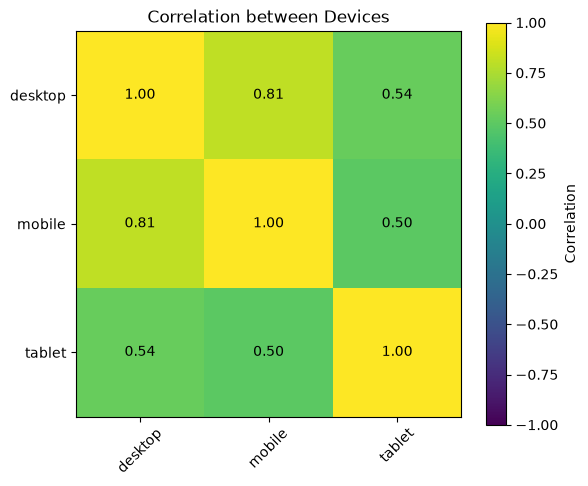

In [190]:
corr_matrix = devices_daily.corr()

plt.figure(figsize=(6, 5))

plt.imshow(corr_matrix, vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation between Devices")
plt.tight_layout()
plt.show()

### Findings

The strongest relationship is observed between **desktop** and **mobile** sales
(**r = 0.81**), indicating a strong positive correlation. This suggests that
when sales increase on desktop devices, mobile sales also tend to increase.

The relationships between **desktop and tablet** (**r = 0.54**) and between
**mobile and tablet** (**r = 0.50**) are moderate and positive. Tablet sales
generally follow the same overall trend but exhibit greater variability than
desktop and mobile sales.

Overall, sales dynamics across device types are positively correlated,
suggesting that common factors such as seasonality, promotions or changes in
overall customer demand affect all device segments simultaneously.

## Overall Findings

The correlation analysis demonstrates that most business metrics are positively
related. The strongest relationship is observed between the number of daily
sessions and daily revenue, confirming that increased website traffic is
generally associated with higher sales.

Positive correlations are also observed across continents, traffic channels,
device types and browsers, indicating that sales dynamics are influenced by
common factors such as overall customer demand, seasonality and marketing
campaigns rather than by isolated market segments.

Most statistically significant relationships have **p-values below 0.05**,
suggesting that the observed correlations are unlikely to occur by chance.
Overall, the analysis indicates that changes in sales tend to occur
simultaneously across different customer groups and business dimensions.

## Statistical Analysis of Group Differences

This section compares different user groups using statistical hypothesis
testing. Before selecting a statistical test, the distribution of each sample
is examined to determine whether parametric or non-parametric methods are
appropriate.

The significance level for all statistical tests is set to **α = 0.05**.

In [193]:
df["session_date"] = pd.to_datetime(df["session_date"])

df["has_account"] = df["account_id"].notna()
df["has_purchase"] = df["price"].notna()

sales_df = df[df["has_purchase"]].copy()

In [194]:
def interpret_p_value(p_value: float, alpha: float = 0.05) -> str:
    if p_value < alpha:
        return "The result is statistically significant."
    
    return "The result is not statistically significant."

In [195]:
def check_normality(sample, alpha: float = 0.05):
    sample = pd.Series(sample).dropna()

    if len(sample) < 8:
        return np.nan, "The sample is too small for the normality test."

    statistic, p_value = normaltest(sample)

    if p_value < alpha:
        conclusion = "The distribution differs significantly from normal."
    else:
        conclusion = "There is insufficient evidence against normality."

    return p_value, conclusion

In [196]:
daily_registration_sales = (
    df.groupby(
        ["session_date", "has_account"],
        as_index=False
    )
    .agg(total_revenue=("price", "sum"))
)

In [197]:
registration_sales_pivot = (
    daily_registration_sales.pivot(
        index="session_date",
        columns="has_account",
        values="total_revenue"
    )
    .fillna(0)
    .rename(columns={
        False: "unregistered_revenue",
        True: "registered_revenue"
    })
)

registration_sales_pivot.head()

has_account,unregistered_revenue,registered_revenue
session_date,,
2020-11-01,"222,745.50","21,547.00"
2020-11-02,"310,550.00","44,956.80"
2020-11-03,"469,829.10","29,150.50"
2020-11-04,"318,204.90","20,982.20"
2020-11-05,"365,942.00","25,334.60"


In [198]:
registered_sample = registration_sales_pivot["registered_revenue"]
unregistered_sample = registration_sales_pivot["unregistered_revenue"]

print(f"Number of dates: {len(registration_sales_pivot)}")
print(f"Registered mean daily revenue: ${registered_sample.mean():,.2f}")
print(f"Unregistered mean daily revenue: ${unregistered_sample.mean():,.2f}")

Number of dates: 92
Registered mean daily revenue: $28,070.85
Unregistered mean daily revenue: $319,447.96


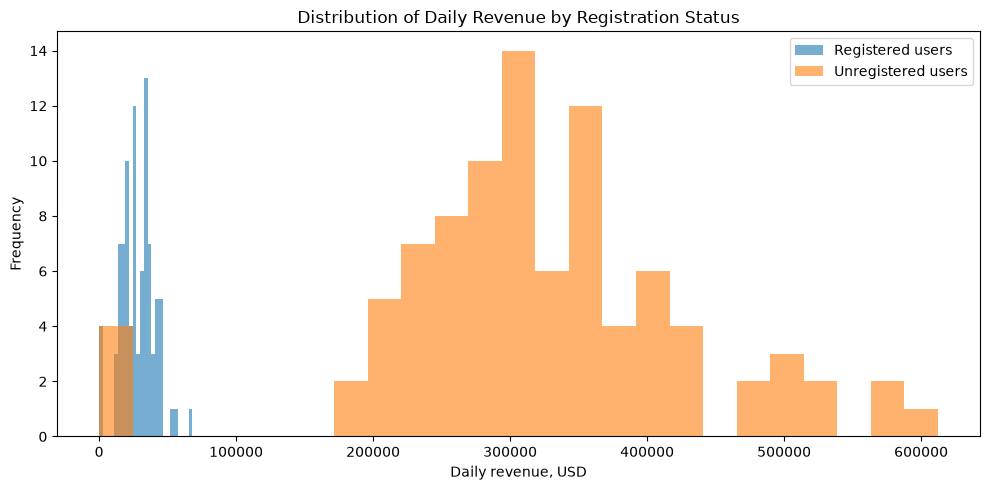

In [199]:
plt.figure(figsize=(10, 5))

plt.hist(
    registered_sample,
    bins=25,
    alpha=0.6,
    label="Registered users"
)

plt.hist(
    unregistered_sample,
    bins=25,
    alpha=0.6,
    label="Unregistered users"
)

plt.title("Distribution of Daily Revenue by Registration Status")
plt.xlabel("Daily revenue, USD")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

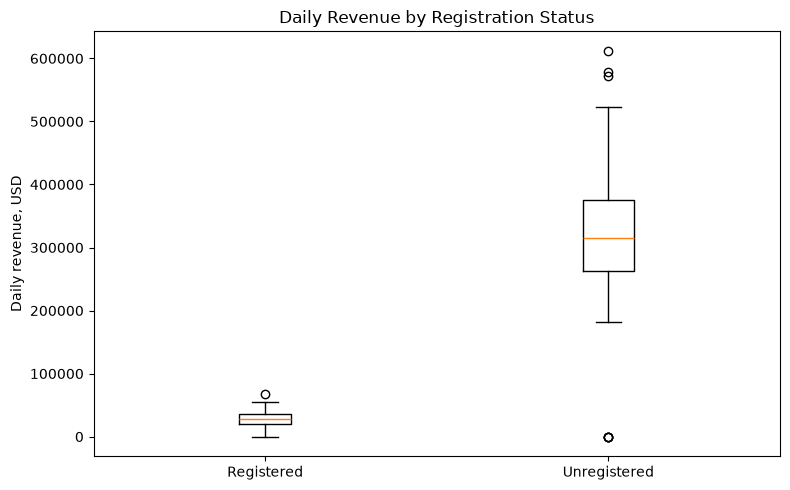

In [200]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [registered_sample, unregistered_sample],
    tick_labels=["Registered", "Unregistered"]
)

plt.title("Daily Revenue by Registration Status")
plt.ylabel("Daily revenue, USD")
plt.tight_layout()
plt.show()

In [201]:
revenue_difference = (
    registered_sample - unregistered_sample
)

normality_p, normality_conclusion = check_normality(
    revenue_difference
)

print(f"Normality p-value: {normality_p:.5f}")
print(normality_conclusion)

Normality p-value: 0.03850
The distribution differs significantly from normal.


In [202]:
alpha = 0.05

if normality_p >= alpha:
    test_name = "Paired t-test"

    statistic, p_value = ttest_rel(
        registered_sample,
        unregistered_sample
    )

else:
    test_name = "Wilcoxon signed-rank test"

    statistic, p_value = wilcoxon(
        registered_sample,
        unregistered_sample
    )

print(f"Selected test: {test_name}")
print(f"Statistic: {statistic:.3f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.5f}")

print(interpret_p_value(p_value))

Selected test: Wilcoxon signed-rank test
Statistic: 0.000
P-value: < 0.001
The result is statistically significant.


In [203]:
mean_difference = (
    registered_sample.mean()
    - unregistered_sample.mean()
)

median_difference = (
    registered_sample.median()
    - unregistered_sample.median()
)

print(f"Mean daily difference: ${mean_difference:,.2f}")
print(f"Median daily difference: ${median_difference:,.2f}")

Mean daily difference: $-291,377.11
Median daily difference: $-287,937.25


### Registered vs Unregistered Users

The distribution of paired daily revenue differences is **not approximately normal**
(normality test p-value = **0.0385**). Therefore, the **Wilcoxon signed-rank test**
was used instead of a paired t-test.

The test returned a p-value below **0.001**, indicating a statistically significant
difference in daily revenue between registered and unregistered users.

Unregistered users generated substantially higher daily revenue during the analyzed
period: mean daily revenue was approximately **$319,447.96** for unregistered users
and **$28,070.85** for registered users. The median paired daily difference was
approximately **-$287,937.25** when calculated as registered minus unregistered
revenue.

This comparison is based on aggregated daily revenue. It identifies an association
between registration status and revenue but does not establish that registration
status causes the observed difference.

In [204]:
known_channels_df = df[
    df["channel"].notna()
].copy()

top_5_channels = (
    known_channels_df.groupby("channel")["ga_session_id"]
    .nunique()
    .nlargest(5)
    .index
)

top_5_channels

Index(['Organic Search', 'Paid Search', 'Direct', 'Social Search',
       'Undefined'],
      dtype='str', name='channel')

In [205]:
daily_channel_sessions = (
    known_channels_df[
        known_channels_df["channel"].isin(top_5_channels)
    ]
    .groupby(
        ["session_date", "channel"],
        as_index=False
    )
    .agg(sessions=("ga_session_id", "nunique"))
)

In [206]:
channel_sessions_pivot = (
    daily_channel_sessions.pivot(
        index="session_date",
        columns="channel",
        values="sessions"
    )
    .fillna(0)
)

channel_sessions_pivot.head()

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
session_date,,,,,
2020-11-01,608,920,706,214,128
2020-11-02,810,1242,970,315,262
2020-11-03,1216,1871,1367,392,327
2020-11-04,935,1425,1145,368,311
2020-11-05,845,1293,917,346,342


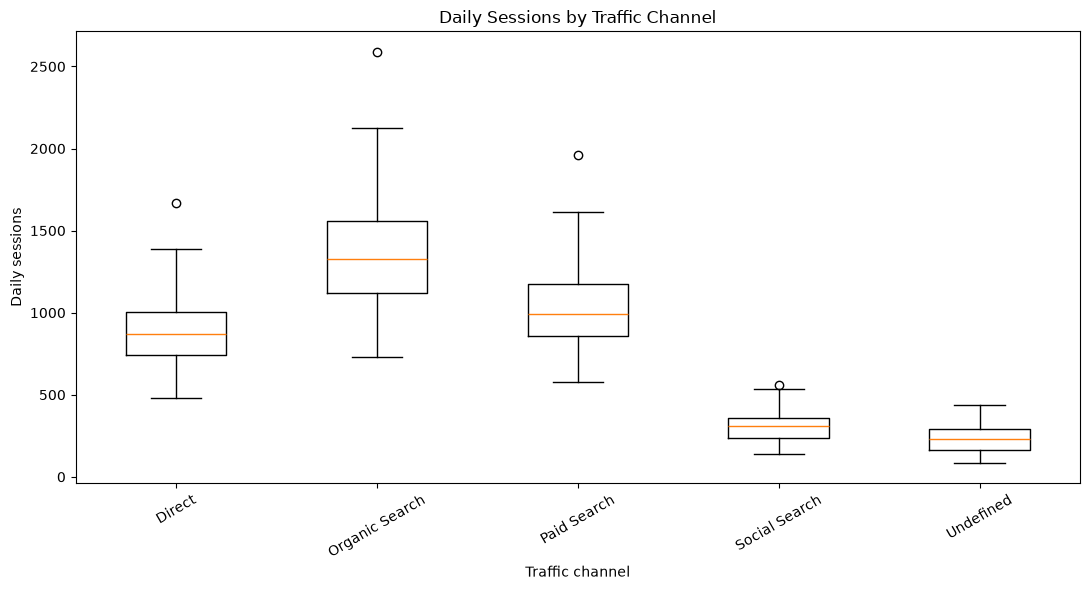

In [207]:
plt.figure(figsize=(11, 6))

plt.boxplot(
    [
        channel_sessions_pivot[channel]
        for channel in channel_sessions_pivot.columns
    ],
    tick_labels=channel_sessions_pivot.columns
)

plt.title("Daily Sessions by Traffic Channel")
plt.xlabel("Traffic channel")
plt.ylabel("Daily sessions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [208]:
friedman_statistic, friedman_p = friedmanchisquare(
    *[
        channel_sessions_pivot[channel]
        for channel in channel_sessions_pivot.columns
    ]
)

print(f"Friedman statistic: {friedman_statistic:.3f}")

if friedman_p < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {friedman_p:.5f}")

print(interpret_p_value(friedman_p))

Friedman statistic: 368.000
P-value: < 0.001
The result is statistically significant.


In [209]:
channel_session_summary = pd.DataFrame({
    "median_daily_sessions": channel_sessions_pivot.median(),
    "mean_daily_sessions": channel_sessions_pivot.mean()
}).sort_values(
    "median_daily_sessions",
    ascending=False
)

channel_session_summary

,median_daily_sessions,mean_daily_sessions
channel,,
Organic Search,"1,329.00","1,352.45"
Paid Search,989.00,"1,025.45"
Direct,869.50,884.59
Social Search,308.00,303.41
Undefined,229.00,233.51


### Sessions by Traffic Channel

The Friedman test was used because session counts for multiple traffic channels were
measured repeatedly across the same dates and normality was not assumed.

The test returned a p-value below **0.001**, indicating statistically significant
differences in daily session volumes among the five leading traffic channels.

**Organic Search** had the highest median number of daily sessions
(**1,329**), while **Undefined** had the lowest (**229**). Paid Search ranked
second, followed by Direct and Social Search.

Because the Friedman test only confirms that at least one channel differs, pairwise
post-hoc comparisons would be required to identify the specific channel pairs with
statistically significant differences.

In [215]:
desktop_prices = sales_df.loc[
    sales_df["device"] == "desktop",
    "price"
].dropna()

mobile_prices = sales_df.loc[
    sales_df["device"] == "mobile",
    "price"
].dropna()

print(f"Desktop purchases: {len(desktop_prices):,}")
print(f"Mobile purchases: {len(mobile_prices):,}")

print(f"Desktop median price: ${desktop_prices.median():,.2f}")
print(f"Mobile median price: ${mobile_prices.median():,.2f}")

Desktop purchases: 19,702
Mobile purchases: 13,113
Desktop median price: $445.00
Mobile median price: $435.00


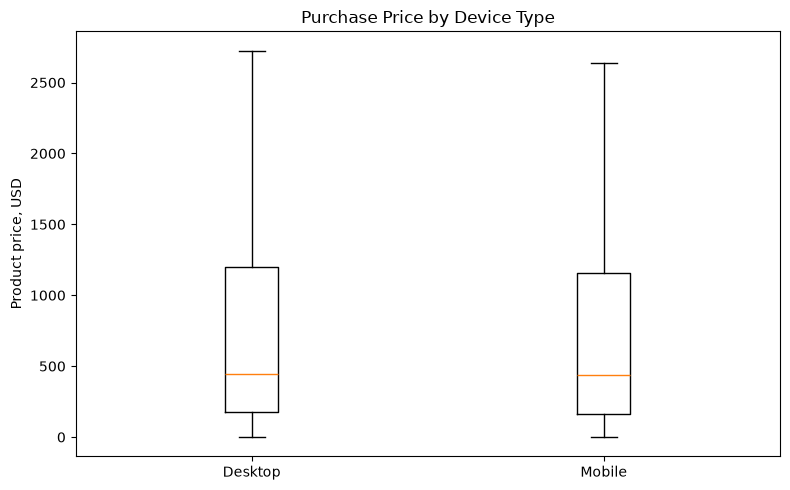

In [216]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [desktop_prices, mobile_prices],
    tick_labels=["Desktop", "Mobile"],
    showfliers=False
)

plt.title("Purchase Price by Device Type")
plt.ylabel("Product price, USD")
plt.tight_layout()
plt.show()

In [217]:
mw_statistic, mw_p = mannwhitneyu(
    desktop_prices,
    mobile_prices,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {mw_statistic:.3f}")

if mw_p < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {mw_p:.5f}")

print(interpret_p_value(mw_p))

Mann–Whitney U statistic: 130361108.500
P-value: 0.15860
The result is not statistically significant.


### Desktop vs Mobile Purchase Prices

The Mann–Whitney U test was used because purchase prices were not assumed to follow
a normal distribution.

The test returned a p-value of **0.1586**, which is above the 0.05 significance
threshold. Therefore, there is insufficient evidence to conclude that desktop and
mobile purchase-price distributions differ statistically.

The median product price was slightly higher for **desktop users** **445 USD** than for **mobile users** **435 USD**. However, the difference was small
and not statistically significant.

In [218]:
top_3_purchase_continents = (
    sales_df.groupby("continent")["ga_session_id"]
    .nunique()
    .nlargest(3)
    .index
)

top_3_purchase_continents

Index(['Americas', 'Asia', 'Europe'], dtype='str', name='continent')

In [219]:
continent_price_samples = {
    continent: sales_df.loc[
        sales_df["continent"] == continent,
        "price"
    ].dropna()
    for continent in top_3_purchase_continents
}

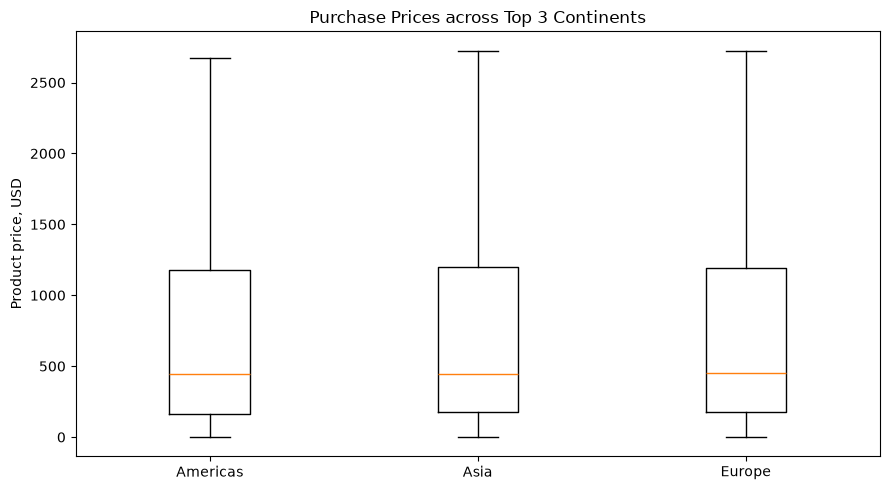

In [220]:
plt.figure(figsize=(9, 5))

plt.boxplot(
    list(continent_price_samples.values()),
    tick_labels=list(continent_price_samples.keys()),
    showfliers=False
)

plt.title("Purchase Prices across Top 3 Continents")
plt.ylabel("Product price, USD")
plt.tight_layout()
plt.show()

In [221]:
kw_statistic, kw_p = kruskal(
    *continent_price_samples.values()
)

print(f"Kruskal–Wallis statistic: {kw_statistic:.3f}")

if kw_p < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {kw_p:.5f}")

print(interpret_p_value(kw_p))

Kruskal–Wallis statistic: 2.903
P-value: 0.23420
The result is not statistically significant.


### Purchase Prices across Continents

The Kruskal–Wallis test returned a p-value of **0.2342**, which is above the
0.05 significance threshold. Therefore, there is insufficient evidence to conclude
that purchase-price distributions differ statistically across the Americas, Asia,
and Europe.

Although the sample medians may differ slightly, the observed variation is not large
enough to be considered statistically significant based on this test.

The Kruskal–Wallis test evaluates whether at least one group differs from the others.
Pairwise post-hoc tests would only be necessary if the overall result were
statistically significant.

## Overall Findings

The statistical analysis identified clear differences in some business dimensions,
while other comparisons did not produce statistically significant results.

Daily revenue differed significantly between registered and unregistered users.
During the analyzed period, unregistered users generated substantially higher
aggregated daily revenue.

Daily session volumes also differed significantly among the leading traffic channels.
Organic Search had the highest median number of daily sessions, while the Undefined
channel had the lowest.

In contrast, purchase-price distributions did not differ significantly between
desktop and mobile users. Likewise, no statistically significant differences were
found in purchase prices across the Americas, Asia, and Europe.

Overall, the results indicate that registration status and traffic channel are
associated with meaningful differences in revenue and session volume, whereas product
prices remain comparatively consistent across major device and geographic groups.
These findings describe statistical associations and should not be interpreted as
evidence of causal relationships.

## Interactive Dashboard

An interactive dashboard was created in Tableau Public to visualize the key
findings from this project.

The dashboard consists of two pages:

- **Sales Overview**
- **Traffic & Customer Insights**

**Tableau Public:**  
> *(https://public.tableau.com/app/profile/dmytro.klymchuk/viz/E-commerceSalesCustomerAnalytics_17851452678650/SalesOverview#1)*

## Final Conclusions

This project analyzed customer sessions, purchases, traffic sources and user
behaviour using SQL, Python, statistical analysis and Tableau.

### Key Findings

- Organic traffic is one of the most important acquisition channels.
- Sales performance varies across countries, categories and device types.
- User behaviour differs between registered and unregistered customers.
- Statistical tests identified significant differences for several customer
  groups where appropriate.
- Tableau dashboards summarize the main business insights in an interactive
  format.

Overall, the project demonstrates a complete end-to-end analytics workflow,
including SQL data extraction, exploratory data analysis, statistical testing
and dashboard development.
